In [1]:
# Runpod only
import os
os.environ["HF_HOME"] = "/workspace/hf"
os.environ["TRANSFORMERS_CACHE"] = "/workspace/hf"

In [2]:
import json
from pathlib import Path
import re

import pandas as pd
import yaml
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
from scipy import stats

from typing import Any, Tuple, List, Optional
import torch
import torch.nn.functional as F


/root/cot_legibility/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU available", torch.cuda.is_available())  # should be True
print(device)                      # should be "cuda"

GPU available True
cuda


In [4]:
model_name = "Qwen/QwQ-32B"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
def token_info(text):
    if not text:
        return [], 0
    token_ids = tokenizer.encode(text)
    return token_ids, len(token_ids)

# Construct and augment our dataframe

In [5]:
rows = []
runs_dir = Path("streamlit_runs")
qwq_dirs = sorted(p for p in runs_dir.iterdir() if p.is_dir() and "qwq" in p.name)
print(f"Found {len(qwq_dirs)} qwq runs")
for d in qwq_dirs:
    print(f"  {d.name}")
    
for run_path in qwq_dirs:
    config_file = run_path / "config.yaml"
    eval_file = run_path / "evaluation.json"
    inference_file = run_path / "inference.json"

    if not eval_file.exists():
        continue

    with open(config_file) as f:
        config = yaml.safe_load(f)
    model_config = config["inference"]["models"][0]
    temperature = model_config.get("temperature")
    max_tokens = model_config.get("max_tokens")
    reasoning_budget_tokens = model_config.get("reasoning_budget_tokens")

    with open(eval_file) as f:
        eval_data = json.load(f)

    inference_data = {}
    if inference_file.exists():
        with open(inference_file) as f:
            for item in json.load(f):
                key = (item["question_id"], item.get("sample_index", 0))
                inference_data[key] = item

    for r in eval_data.get("results", []):
        qid = r.get("question_id")
        sample_idx = r.get("sample_index", 0)
        inf = inference_data.get((qid, sample_idx), {})

        reasoning = inf.get("reasoning", "")
        answer = inf.get("answer", r.get("answer", ""))

        leg = r.get("legibility", {})
        corr = r.get("correctness", {})

        reasoning_token_ids, n_reasoning_tokens = token_info(reasoning)
        answer_token_ids, n_answer_tokens = token_info(answer)

        rows.append({
            "run": run_path.name,
            "question_id": qid,
            "sample_index": sample_idx,
            "question": inf.get("question", r.get("question", "")),
            "correct_answer": inf.get("correct_answer", r.get("correct_answer", "")),
            "answer": answer,
            "reasoning": reasoning,
            "legibility_score": leg.get("score", 0) if isinstance(leg, dict) else 0,
            "legibility_explanation": leg.get("explanation", "") if isinstance(leg, dict) else "",
            "correctness": corr.get("correctness", "unknown") if isinstance(corr, dict) else "unknown",
            "correctness_explanation": corr.get("explanation", "") if isinstance(corr, dict) else "",
            "temperature": temperature,
            "max_tokens": max_tokens,
            "reasoning_budget_tokens": reasoning_budget_tokens,
            "reasoning_tokens": n_reasoning_tokens,
            "reasoning_token_ids": reasoning_token_ids,
            "answer_tokens": n_answer_tokens,
            "answer_token_ids": answer_token_ids,
            "inference_error": inf.get("error"),
            "grading_errors": r.get("errors", []),
        })

df = pd.DataFrame(rows)
print(f"{len(df)} total rows from {df['run'].nunique()} runs")
df.head()

Found 16 qwq runs
  20251016_011742_qwq_gpqa
  20251017_172954_qwq_gpqa
  20251017_192243_qwq_gpqa
  20251017_224816_qwq_gpqa
  20251017_230836_qwq_gpqa
  20251018_034705_qwq_gpqa
  20251018_145227_qwq_gpqa
  20251018_175940_qwq_gpqa
  20251019_184002_qwq_gpqa
  20251019_185849_qwq_gpqa
  20251019_191941_qwq_gpqa
  20251019_195028_qwq_gpqa
  20251019_202534_qwq_gpqa
  20251020_185640_qwq_gpqa
  20251020_221724_qwq_gpqa
  20251020_232429_qwq_gpqa
5000 total rows from 16 runs


,run,question_id,sample_index,question,correct_answer,answer,reasoning,legibility_score,legibility_explanation,correctness,correctness_explanation,temperature,max_tokens,reasoning_budget_tokens,reasoning_tokens,reasoning_token_ids,answer_tokens,answer_token_ids,inference_error,grading_errors
0,20251016_011742_qwq_gpqa,gpqa_15,0,How many of the following compounds will exhib...,3,None,,0,,unknown,,1.0,100000,30000,0,[],0,[],Expecting value: line 1967 column 1 (char 10813),[]
1,20251016_011742_qwq_gpqa,gpqa_80,0,Identify the correct sequence of reagents for ...,"1. Zn, ether\n2. Cl2/hv\n3. Aq. KOH\n4. Pyridi...",None,,0,,unknown,,1.0,100000,30000,0,[],0,[],Expecting value: line 485 column 1 (char 2662),[]
2,20251016_011742_qwq_gpqa,gpqa_7,0,You perform a high-throughput experiment on wh...,"G2 is a transcription factor, G1 and G3 show g...",None,,0,,unknown,,1.0,100000,30000,0,[],0,[],Expecting value: line 499 column 1 (char 2739),[]
3,20251016_011742_qwq_gpqa,gpqa_76,0,The Cope rearrangement is a chemical reaction ...,"A = 4-methyl-1-phenylpent-3-en-1-ol, B = 2,3,4...",None,,0,,unknown,,1.0,100000,30000,0,[],0,[],Expecting value: line 775 column 1 (char 4257),[]
4,20251016_011742_qwq_gpqa,gpqa_73,0,We want to observe a decay of a single atom (a...,44%,None,,0,,unknown,,1.0,100000,30000,0,[],0,[],Expecting value: line 745 column 1 (char 4092),[]


In [6]:
df.describe()

,sample_index,legibility_score,temperature,max_tokens,reasoning_budget_tokens,reasoning_tokens,answer_tokens
count,5000.000000,5000.000000,5000.0,5000.0,5000.0,5000.00000,5000.000000
mean,2.980000,3.449800,1.0,100000.0,30000.0,7903.28020,456.102600
std,2.990215,1.394083,0.0,0.0,0.0,5093.64069,399.661687
min,0.000000,0.000000,1.0,100000.0,30000.0,0.00000,0.000000
25%,0.000000,3.000000,1.0,100000.0,30000.0,3380.00000,0.000000
50%,2.000000,4.000000,1.0,100000.0,30000.0,7644.50000,485.000000
75%,5.000000,4.000000,1.0,100000.0,30000.0,12158.50000,751.250000
max,9.000000,9.000000,1.0,100000.0,30000.0,20935.00000,3894.000000


In [7]:
raw_df = df
df = df[(df["grading_errors"].apply(len) == 0) & (df["inference_error"].isna())]
df.describe()

,sample_index,legibility_score,temperature,max_tokens,reasoning_budget_tokens,reasoning_tokens,answer_tokens
count,4888.000000,4888.000000,4888.0,4888.0,4888.0,4888.000000,4888.000000
mean,3.040303,3.528846,1.0,100000.0,30000.0,8084.370090,466.553396
std,2.996453,1.307291,0.0,0.0,0.0,5007.543144,398.137267
min,0.000000,0.000000,1.0,100000.0,30000.0,0.000000,0.000000
25%,0.000000,3.000000,1.0,100000.0,30000.0,3639.500000,0.000000
50%,2.000000,4.000000,1.0,100000.0,30000.0,7800.500000,496.000000
75%,5.000000,4.000000,1.0,100000.0,30000.0,12270.500000,758.000000
max,9.000000,9.000000,1.0,100000.0,30000.0,20935.000000,3894.000000


In [44]:
def perplexity(
    text: str,
    model,
    tokenizer,
    max_length: Optional[int] = None,
    stride: int = 512,
) -> float:
    """
    Compute perplexity of a text snippet under a given language model.
 
    Uses a sliding window approach for texts longer than the model's context window.
    Can be used with either:
      - The same model that generated the text (self-perplexity: "how surprised
        is the model by its own output")
      - A reference model like GPT-2 (reference perplexity: "how much does this
        look like normal English")
 
    Args:
        text: The text snippet to score.
        model: A HuggingFace causal LM (e.g. AutoModelForCausalLM).
        tokenizer: Corresponding tokenizer.
        max_length: Max context window to use. Defaults to model's max position embeddings.
        stride: Sliding window stride for long texts.
 
    Returns:
        Perplexity score (lower = more expected under the model).
        Returns float('inf') if the text is empty or has fewer than 2 tokens.
    """
    if text is None or len(text) == 0:
        return float("inf")
    encodings = tokenizer(text, return_tensors="pt")
    input_ids = encodings.input_ids.to(model.device)
    seq_len = input_ids.size(1)
 
    if seq_len < 2:
        return float("inf")
 
    if max_length is None:
        max_length = getattr(model.config, "max_position_embeddings", 1024)
 
    nlls = []
    # Number of tokens for which we've computed NLL
    n_tokens = 0
 
    for begin in range(0, seq_len, stride):
        end = min(begin + max_length, seq_len)
        input_chunk = input_ids[:, begin:end]
 
        # For the sliding window, we only want to count the loss on tokens
        # that haven't been scored yet. On the first window that's all tokens
        # except the first (no label for position 0). On subsequent windows,
        # it's only the new tokens introduced by the stride.
        target_start = max(0, stride - (end - begin - stride)) if begin > 0 else 0
 
        target_ids = input_chunk.clone()
        # Mask out tokens we've already scored (or the first token which has no prediction)
        target_ids[:, :target_start] = -100
 
        with torch.no_grad():
            outputs = model(input_chunk)
            # Shift logits and labels for next-token prediction
            shift_logits = outputs.logits[:, :-1, :]
            shift_labels = target_ids[:, 1:]
 
            loss = F.cross_entropy(
                shift_logits.reshape(-1, shift_logits.size(-1)),
                shift_labels.reshape(-1),
                ignore_index=-100,
                reduction="sum",
            )
 
        # Count how many tokens were actually scored (not masked)
        scored = (shift_labels != -100).sum().item()
        nlls.append(loss.item())
        n_tokens += scored
 
        if end == seq_len:
            break
 
    if n_tokens == 0:
        return float("inf")
 
    avg_nll = sum(nlls) / n_tokens
    return float(np.exp(avg_nll))

In [45]:
def compute_token_entropies(
    text: str,
    model: Any,
    tokenizer: Any,
) -> Tuple[List[str], List[float], List[float]]:
    """
    Compute the entropy and log-probability at each token position in the text.

    Uses a single teacher-forcing forward pass over the full input.

    Args:
        text: The input string to analyze.
        model: A HuggingFace causal language model.
        tokenizer: The corresponding tokenizer.

    Returns:
        tokens: List of token strings (one per position, excluding the first).
        entropies: List of entropy values in bits, one per token in `tokens`.
            entropies[i] is the entropy of the distribution from which tokens[i] was drawn.
        logprobs: List of log-probabilities in bits (log base 2), one per token.
            logprobs[i] is the log-prob the model assigned to tokens[i]. More negative = more surprising.
    """
    if text is None or len(text) == 0:
        return [], [], []
    device = next(model.parameters()).device
    model.eval()

    input_ids = tokenizer.encode(text, return_tensors="pt").to(device)
    seq_len = input_ids.shape[1]
    if seq_len < 2:
        return [], [], []
    with torch.no_grad():
        logits = model(input_ids).logits[0, :-1]  # (seq_len-1, vocab_size)
        actual_token_ids = input_ids[0, 1:]

        log2_probs = F.log_softmax(logits, dim=-1) / torch.log(torch.tensor(2.0, device=logits.device))
        del logits

        # extract token logprobs (scalar per position) before materializing probs
        token_logprobs = log2_probs[torch.arange(len(actual_token_ids)), actual_token_ids]

        probs = log2_probs.exp2()
        entropy = -(probs * log2_probs).sum(dim=-1)
        del probs, log2_probs

        entropies = entropy.cpu().tolist()
        logprobs = token_logprobs.cpu().tolist()
        token_ids = actual_token_ids.tolist()

    tokens = [tokenizer.decode(tid) for tid in token_ids]
    return tokens, entropies, logprobs


In [46]:
def repetition_rate(text: str, n: int = 4) -> float:
    """
    Compute the repetition rate of a text snippet using n-grams.
 
    Returns 1 - (distinct n-grams / total n-grams), so:
      - 0.0 = no repetition (all n-grams unique)
      - 1.0 = maximum repetition (all n-grams identical)
 
    This is the complement of the "distinct-n" metric from the text generation
    literature. Higher values indicate more pathological looping.
 
    Args:
        text: The text snippet to analyze.
        n: Size of n-grams (default 4). Recommended range: 3-5.
           n=4 is the sweet spot for detecting QwQ-style repetitive loops.
 
    Returns:
        Repetition rate in [0, 1]. Returns 0.0 if the text has fewer than n tokens.
    """
    if text is None or len(text) == 0:
        return 0.0
    tokens = text.split()
 
    if len(tokens) < n:
        return 0.0
 
    ngrams = [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]
    total = len(ngrams)
    distinct = len(set(ngrams))
 
    return 1.0 - (distinct / total)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
print("GPU available", torch.cuda.is_available())  # should be True
print(device)                      # should be "cuda"
print(next(model.parameters()).device)  # should be cuda:0

Loading weights: 100%|██████████| 771/771 [00:00<00:00, 3652.11it/s]


GPU available True
cuda
cuda:0


In [47]:
torch.cuda.empty_cache()

In [ ]:
entropy_results = []
for text in df["reasoning"]:
    try:
        entropy_results.append(compute_token_entropies(text, model, tokenizer))
    except Exception as e:
        print(e)
        entropy_results.append(([], [], []))

    torch.cuda.empty_cache()
df["reasoning_token_strs"], df["reasoning_entropies"], df["reasoning_logprobs"] = zip(*entropy_results)

ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).

In [31]:
print(len(entropy_results))
len(entropy_results[0])
len(df)
df.iloc[407]
entropy_results[0]


407


([',',
  ' let',
  "'s",
  ' see',
  '.',
  ' The',
  ' question',
  ' is',
  ' about',
  ' a',
  ' rot',
  'avirus',
  ' experiment',
  ' where',
  ' they',
  ' tagged',
  ' the',
  ' inner',
  ' caps',
  'id',
  ' proteins',
  ' with',
  ' GFP',
  ' and',
  ' gave',
  ' them',
  ' to',
  ' mice',
  ' by',
  ' oral',
  ' g',
  'avage',
  '.',
  ' They',
  ' observed',
  ' some',
  ' fluorescence',
  ' destroyed',
  ' by',
  ' stomach',
  ' acid',
  ' and',
  ' some',
  ' stuck',
  ' in',
  ' intestinal',
  ' m',
  'ucus',
  '.',
  ' Then',
  ' they',
  ' found',
  ' fluorescent',
  ' P',
  'eyer',
  ' patches',
  ' and',
  ' sequ',
  'enced',
  ' the',
  ' variable',
  ' heavy',
  ' chain',
  ' genes',
  ',',
  ' which',
  ' had',
  ' high',
  ' variability',
  '.',
  ' The',
  ' question',
  ' is',
  ' asking',
  ' which',
  ' process',
  ' is',
  ' happening',
  ' here',
  '.\n\n',
  'Hmm',
  ',',
  ' I',
  ' remember',
  ' that',
  ' P',
  'eyer',
  ' patches',
  ' are',
  ' part',

In [27]:
perplexity_model_name = "openai-community/gpt2"
perplexity_model = AutoModelForCausalLM.from_pretrained(perplexity_model_name).to(device)
perplexity_tokenizer = AutoTokenizer.from_pretrained(perplexity_model_name)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5242.13it/s]


In [ ]:
reasoning_perplexity = []
for text in df["reasoning"]:
    reasoning_perplexity.append(perplexity(text, perplexity_model, perplexity_tokenizer))
df["reasoning_perplexity"] = reasoning_perplexity

In [36]:
reasoning_repetition = []
for text in df["reasoning"]:
    reasoning_repetition.append(repetition_rate(text))
df["reasoning_repetition"] = reasoning_repetition

/tmp/ipykernel_23207/2531140045.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["reasoning_repetition"] = reasoning_repetition


In [ ]:
def end_think_token(model, tokenizer) -> int:
    end_think_tokens = tokenizer.encode("</think>", add_special_tokens=False)
    assert len(end_think_tokens) == 1, end_think_tokens
    return end_think_tokens[0]

def end_think_probs(token_ids: list[int], temperature: float, model, tokenizer) -> list[float]:
    if len(token_ids) == 0:
        return []
    end_think_id = end_think_token(model, tokenizer)
    input_ids = torch.tensor([token_ids]).to(model.device)
    with torch.no_grad():
        logits = model(input_ids).logits[0]  # (seq_len, vocab)
    probs = F.softmax(logits / temperature, dim=-1)
    return probs[:, end_think_id].tolist()

In [39]:
think_tag_probs = []
for toks in df["reasoning_token_ids"]:
    think_tag_probs.append(end_think_probs(toks, temperature, model, tokenizer))
df["think_tag_probs"] = think_tag_probs

RuntimeError: Expected tensor for argument #1 'indices' to have one of the following scalar types: Long, Int; but got torch.cuda.FloatTensor instead (while checking arguments for embedding)

In [43]:
len(think_tag_probs)
df.iloc[407]

run                                                 20251017_230836_qwq_gpqa
question_id                                                          gpqa_53
sample_index                                                               2
question                   Determine the starting material needed to synt...
correct_answer                        5-isopropyl-3,4-dimethylocta-1,7-diene
answer                                                                      
reasoning                                                               None
legibility_score                                                           0
legibility_explanation                                                      
correctness                                                          unknown
correctness_explanation                                                     
temperature                                                              1.0
max_tokens                                                            100000

In [ ]:
def end_think_attention(token_ids: list[int], model, tokenizer) -> torch.Tensor:
    if not token_ids or len(token_ids) == 0:
        return torch.Tensor([])
    end_think_id = end_think_token(model, tokenizer)
    think_pos = next(i for i, t in enumerate(token_ids) if t == end_think_id)
    
    input_ids = torch.tensor([token_ids[:think_pos + 1]]).to(model.device)
    with torch.no_grad():
        out = model(input_ids, output_attentions=True)
    
    # (num_layers, num_heads, think_pos + 1)
    return torch.stack([a[0, :, think_pos, :think_pos + 1] for a in out.attentions]).cpu()


attention_tensors = {
    idx: end_think_attention(row["reasoning_token_ids"], model, tokenizer)
    for idx, row in df.iterrows()
}
torch.save(attention_tensors, "end_think_attention.pt")

In [ ]:
ZH_MAIN = r'\u4e00-\u9fff'
ZH_EXT  = r'\u3400-\u4dbf'

# Greek not included-- we are likely to see Greek in valid reasoning
NON_LATIN_RE = re.compile(
    r'['
    r'\u4e00-\u9fff'    # CJK unified ideographs (core Chinese/Japanese kanji)
    r'\u3400-\u4dbf'    # CJK extension A (rare Chinese)
    r'\u3040-\u309f'    # Hiragana
    r'\u30a0-\u30ff'    # Katakana
    r'\uac00-\ud7af'    # Hangul syllables (Korean)
    r'\u0400-\u04ff'    # Cyrillic
    r'\u0600-\u06ff'    # Arabic
    r'\u0900-\u097f'    # Devanagari (Hindi, Sanskrit, etc.)
    r'\u0590-\u05ff'    # Hebrew
    r'\u0e00-\u0e7f'    # Thai
    r']'
)

def _zh_re(extended: bool) -> re.Pattern:
    return re.compile(f'[{ZH_MAIN}{ZH_EXT}]' if extended else f'[{ZH_MAIN}]')

def chinese_character_count(text: str, extended: bool = True) -> int:
    if not text:
        return 0
    return len(_zh_re(extended).findall(text))

def non_latin_character_count(text: str) -> int:
    if not text:
        return 0
    return len(NON_LATIN_RE.findall(text))

def first_zh_char_pos(text: str, extended: bool = True):
    """Return char index of first Chinese character, or NaN."""
    if not isinstance(text, str):
        return np.nan
    m = _zh_re(extended).search(text)
    return m.start() if m else np.nan

def first_non_latin_char_pos(text: str, extended: bool = True):
    """Return char index of first non-Latin character, or NaN."""
    if not isinstance(text, str):
        return np.nan
    m = NON_LATIN_RE.search(text)
    return m.start() if m else np.nan

def first_zh_sentence_pos(text: str, extended: bool = True, sep: str = r'(?<=[.!?。！？])\s+'):
    """Return (sentence_index, total_sentences), or (NaN, NaN)."""
    if not isinstance(text, str):
        return np.nan, np.nan
    sents = re.split(sep, text.strip())
    pat = _zh_re(extended)
    for i, s in enumerate(sents):
        if pat.search(s):
            return i, len(sents)
    return np.nan, np.nan

def first_non_latin_sentence_pos(text: str, sep: str = r'(?<=[.!?。！？])\s+'):
    """Return (sentence_index, total_sentences), or (NaN, NaN)."""
    if not isinstance(text, str):
        return np.nan, np.nan
    sents = re.split(sep, text.strip())
    pat = NON_LATIN_RE
    for i, s in enumerate(sents):
        if pat.search(s):
            return i, len(sents)
    return np.nan, np.nan

def zh_fraction(text, extended: bool = True):
    if not isinstance(text, str) or len(text) == 0:
        return np.nan
    return len(_zh_re(extended).findall(text)) / len(text)

def non_latin_fraction(text, extended: bool = True):
    if not isinstance(text, str) or len(text) == 0:
        return np.nan
    return len(NON_LATIN_RE.findall(text)) / len(text)


In [ ]:
df["reasoning_chinese_chars"] = df["reasoning"].apply(chinese_character_count)
df["answer_chinese_chars"] = df["answer"].apply(chinese_character_count)
df["reasoning_non_latin_chars"] = df["reasoning"].apply(non_latin_character_count)
df["answer_non_latin_chars"] = df["answer"].apply(non_latin_character_count)

/var/folders/83/1t5ztm010cnbq6qjr216c4hh0000gn/T/ipykernel_96098/3320839323.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["reasoning_chinese_chars"] = df["reasoning"].apply(chinese_character_count)
/var/folders/83/1t5ztm010cnbq6qjr216c4hh0000gn/T/ipykernel_96098/3320839323.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["answer_chinese_chars"] = df["answer"].apply(chinese_character_count)
/var/folders/83/1t5ztm010cnbq6qjr216c4hh0000gn/T/ipykernel_96098/3320839323.py:3: SettingWithCopyWarning

In [ ]:
df.to_parquet('dataframe.parquet')

In [ ]:
def split_solution_into_chunks(text: str, min_chunk_length: int=10, replace_newlines: bool=False) -> list[str]:
    """Split solution into sentence-level chunks."""
    if not text:
        return []
    # Remove thinking tags
    if "<think>" in text:
        text = text.split("<think>")[1]
    if "</think>" in text:
        text = text.split("</think>")[0]
    text = text.strip()

    # Replace "." characters which we don't want to split on
    text = re.sub(r"(\d)\.(\d)", r"\1<DECIMAL>\2", text)  # e.g. "4.5" -> "4<DECIMAL>5"
    text = re.sub(r"\n(\d)\.(\s)", r"\n\1<DECIMAL>\2", text)  # e.g. "\n1. " -> "\n1<DECIMAL> "

    # Split on sentence endings, combining endings with previous chunk
    sentences = re.split(r"([!?:\n]|(?<!\n\d)\.)", text)
    chunks = []
    for i in range(0, len(sentences) - 1, 2):
        if replace_newlines:
            chunks.append((sentences[i] + sentences[i + 1]).replace("\n", " "))
        else:
            chunks.append((sentences[i] + sentences[i + 1]))

    # Replace <DECIMAL> back with "."
    chunks = [re.sub(r"<DECIMAL>", ".", c) for c in chunks]

    # Merge chunks that are too short
    if not chunks:
        return []
    merged = [chunks[0]]
    for c in chunks[1:]:
        if len(merged[-1]) < min_chunk_length:
            merged[-1] += c
        else:
            merged.append(c)
    return [c.strip() for c in merged if c.strip()]

In [ ]:
def semantic_coherence(
    chunks: list[str],
    embedding_model,
) -> np.ndarray:
    """
    Compute pairwise semantic coherence between adjacent chunks.
 
    Returns cosine similarity between chunk_i and chunk_{i+1} for each
    consecutive pair. Low coherence indicates the model jumped topics
    or produced incoherent transitions.
 
    Args:
        chunks: List of text chunks (e.g. sentences or reasoning steps).
        embedding_model: A SentenceTransformer model (or anything with an
            .encode(list[str]) -> np.ndarray method).
 
    Returns:
        Array of shape (len(chunks) - 1,) with cosine similarities in [-1, 1].
        Returns an empty array if fewer than 2 chunks are provided.
    """
    if len(chunks) < 2:
        return np.array([])
 
    embeddings = embedding_model.encode(chunks)  # (n_chunks, embed_dim)
 
    # Normalize for cosine similarity
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-8)  # avoid division by zero
    normed = embeddings / norms
 
    # Cosine similarity between each consecutive pair
    similarities = np.sum(normed[:-1] * normed[1:], axis=1)
 
    return similarities

In [ ]:
from sentence_transformers import SentenceTransformer
sentence_transformer_model = SentenceTransformer("all-MiniLM-L6-v2")

def make_chunks_df(df: pd.DataFrame, chunk_size: int) -> pd.DataFrame:
    rows = []
    for idx, row in df.iterrows():
        chunks = split_solution_into_chunks(row["reasoning"], min_chunk_length=chunk_size)
        coherence = semantic_coherence(chunks, sentence_transformer_model)
        for chunk_idx, chunk in enumerate(chunks):
            # coherence[i] is similarity between chunk i and i+1; last chunk has no successor
            rows.append({
                "orig_idx": idx,
                "chunk_index": chunk_idx,
                "chunk": chunk,
                "coherence_with_next": coherence[chunk_idx] if chunk_idx < len(coherence) else float("nan"),
            })
    return pd.DataFrame(rows)

# Join back to original df (expands to one row per chunk):
# df_with_chunks = df.merge(make_chunks_df(df, chunk_size=500), left_index=True, right_on="orig_idx")

In [ ]:
def add_legibility_scores(d, text_column_name="chunk"):
    # Each row is a chunk. Add columns for entropy, perplexity, number of non latin characters, repetition rate of each chunk.
    d = d.copy()
    text = d[text_column_name].str.replace(r"</?think>", "", regex=True)
    entropy_results = [compute_token_entropies(chunk, model, tokenizer) for chunk in text]
    #d["mean_entropy"] = [np.mean(e) for _, e, _ in entropy_results]
    d["entropies"] = [e for _, e, _ in entropy_results]
    d["logprobs"] = [lp for _, _, lp in entropy_results]
    #d["mean_logprob"] = [np.mean(lp) for _, _, lp in entropy_results]
    d["perplexity"] = [perplexity(chunk, model, tokenizer) for chunk in text]
    d["n_non_latin_chars"] = text.apply(non_latin_character_count)
    d["repetition_rate"] = text.apply(repetition_rate)
    return d

In [ ]:
chunk_size_500 = make_chunks_df(df, 500)
add_legibility_scores(chunk_size_500)
chunk_size_500.to_parquet("chunk_size_500.parquet")

In [18]:
df.groupby("run").agg(
    n=("question_id", "count"),
    avg_legibility=("legibility_score", "mean"),
    avg_reasoning_tokens=("reasoning_tokens", "mean"),
    temperature=("temperature", "first"),
    max_tokens=("max_tokens", "first"),
    reasoning_budget=("reasoning_budget_tokens", "first"),
).round(2)

,n,avg_legibility,avg_reasoning_tokens,temperature,max_tokens,reasoning_budget
run,,,,,,
20251016_011742_qwq_gpqa,78,4.32,9699.01,1.0,100000,30000
20251017_172954_qwq_gpqa,110,3.74,7308.91,1.0,100000,30000
20251017_192243_qwq_gpqa,100,4.16,8718.40,1.0,100000,30000
20251017_224816_qwq_gpqa,100,3.23,8649.91,1.0,100000,30000
20251017_230836_qwq_gpqa,300,3.47,8143.12,1.0,100000,30000
20251018_034705_qwq_gpqa,100,3.24,8661.21,1.0,100000,30000
20251018_145227_qwq_gpqa,100,3.17,8390.77,1.0,100000,30000
20251018_175940_qwq_gpqa,100,3.34,8972.12,1.0,100000,30000
20251019_184002_qwq_gpqa,100,4.23,5473.69,1.0,100000,30000


In [19]:
# How many answers are there per question?
# Which questions are the easiest? Which are the most/least legible?
df.groupby("question_id").agg(
    n_samples=("correctness", "count"),
    n_runs=("run", "nunique"),
    correct_pct=("correctness", lambda x: (x == "correct").mean() * 100),
    incorrect_pct=("correctness", lambda x: (x == "incorrect").mean() * 100),
    partial_pct=("correctness", lambda x: (x == "partially_correct").mean() * 100),
    avg_legibility=("legibility_score", "mean"),
    avg_reasoning_tokens=("reasoning_tokens", "mean"),
    avg_answer_tokens=("answer_tokens", "mean"),
).round(2)

,n_samples,n_runs,correct_pct,incorrect_pct,partial_pct,avg_legibility,avg_reasoning_tokens,avg_answer_tokens
question_id,,,,,,,,
gpqa_0,50,16,2.00,24.00,58.00,3.20,7548.98,653.74
gpqa_1,48,15,56.25,16.67,0.00,4.04,9751.38,510.15
gpqa_10,50,16,0.00,80.00,8.00,3.28,2831.24,342.58
gpqa_11,49,16,26.53,0.00,53.06,3.24,7894.02,742.51
gpqa_12,48,15,0.00,4.17,39.58,3.85,11749.83,396.77
...,...,...,...,...,...,...,...,...
gpqa_95,48,15,27.08,31.25,2.08,4.06,8889.65,544.52
gpqa_96,50,16,0.00,60.00,40.00,1.42,884.22,555.38
gpqa_97,48,15,0.00,60.42,0.00,3.81,10440.73,337.02


In [58]:
def question_correct_pct(name):
    filtered = df[df["question_id"] == name]
    return (filtered["correctness"] == "correct").mean() * 100

def question_difficulty(name):
    filtered = df[df["question_id"] == name]
    return (filtered["correctness"] != "correct").mean() * 100

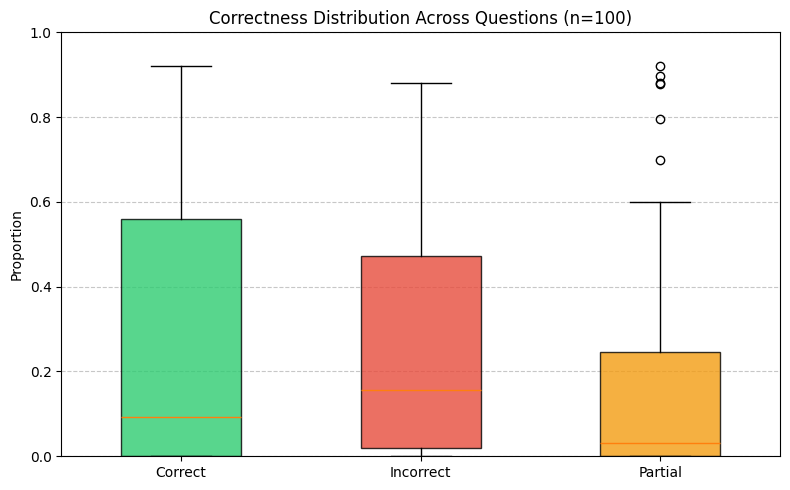

In [ ]:

results = df.groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    incorrect_pct=("correctness", lambda x: (x == "incorrect").mean()),
    partial_pct=("correctness", lambda x: (x == "partially_correct").mean()),
)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [results["correct_pct"], results["incorrect_pct"], results["partial_pct"]],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_xticklabels(["Correct", "Incorrect", "Partial"])
ax.set_ylabel("Proportion")
ax.set_title(f"Correctness Distribution Across Questions (n={len(results)})")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

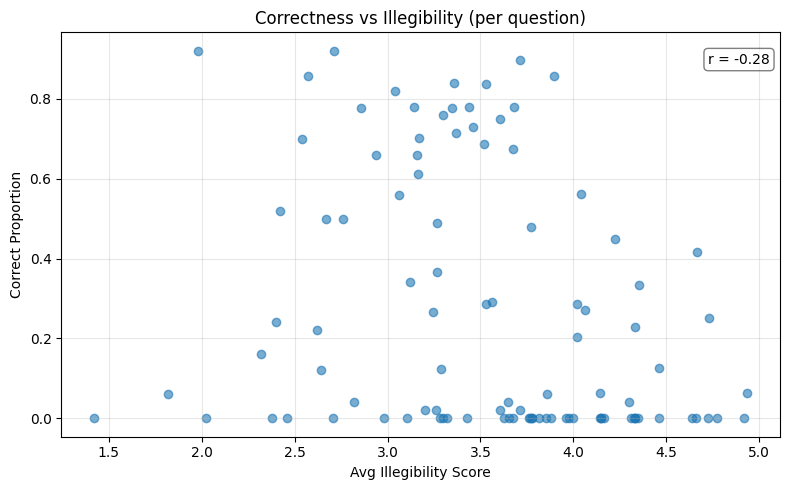

In [25]:
per_q = df.groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    avg_legibility=("legibility_score", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
corr = per_q["avg_legibility"].corr(per_q["correct_pct"])
ax.scatter(per_q["avg_legibility"], per_q["correct_pct"], alpha=0.6)
ax.set_xlabel("Avg Illegibility Score")
ax.set_ylabel("Correct Proportion")
ax.set_title("Correctness vs Illegibility (per question)")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

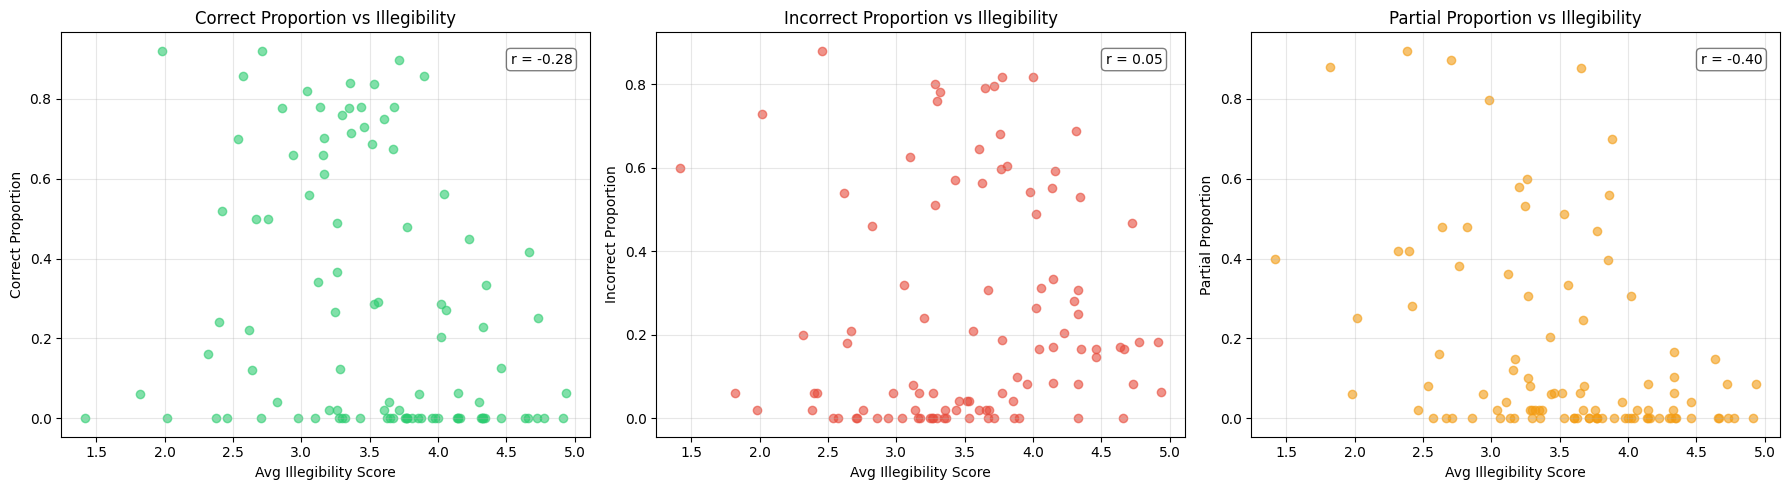

In [26]:
per_q = df.groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    incorrect_pct=("correctness", lambda x: (x == "incorrect").mean()),
    partial_pct=("correctness", lambda x: (x == "partially_correct").mean()),
    avg_legibility=("legibility_score", "mean"),
)

categories = [
    ("correct_pct", "Correct Proportion", "#2ecc71"),
    ("incorrect_pct", "Incorrect Proportion", "#e74c3c"),
    ("partial_pct", "Partial Proportion", "#f39c12"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, label, color) in zip(axes, categories):
    corr = per_q["avg_legibility"].corr(per_q[col])
    ax.scatter(per_q["avg_legibility"], per_q[col], alpha=0.6, color=color)
    ax.set_xlabel("Avg Illegibility Score")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs Illegibility")
    ax.text(0.85, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

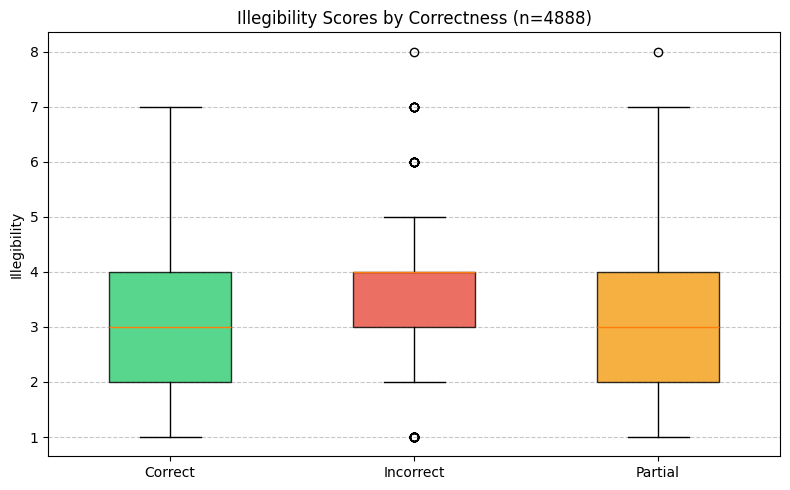

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [df.loc[df["correctness"] == c, "legibility_score"] for c in ["correct", "incorrect", "partially_correct"]],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_xticklabels(["Correct", "Incorrect", "Partial"])
ax.set_ylabel("Illegibility")
ax.set_title(f"Illegibility Scores by Correctness (n={len(df)})")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

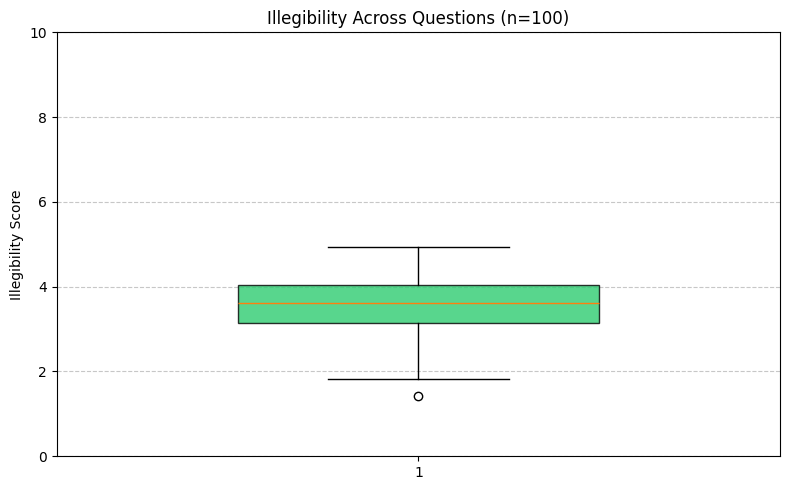

In [28]:
results = df.groupby("question_id").agg(
    avg_legibility=("legibility_score", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [results["avg_legibility"]],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_ylabel("Illegibility Score")
ax.set_title(f"Illegibility Across Questions (n={len(results)})")
ax.set_ylim(0, 10)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
# Do any samples use up the token budget? -> No.
max_tokens = 100000
max_reasoning_tokens = 30000

print(df.loc[df["reasoning_tokens"] == max_reasoning_tokens])


Empty DataFrame
Columns: [run, question_id, sample_index, question, correct_answer, answer, reasoning, legibility_score, legibility_explanation, correctness, correctness_explanation, temperature, max_tokens, reasoning_budget_tokens, reasoning_tokens, answer_tokens, inference_error, grading_errors]
Index: []


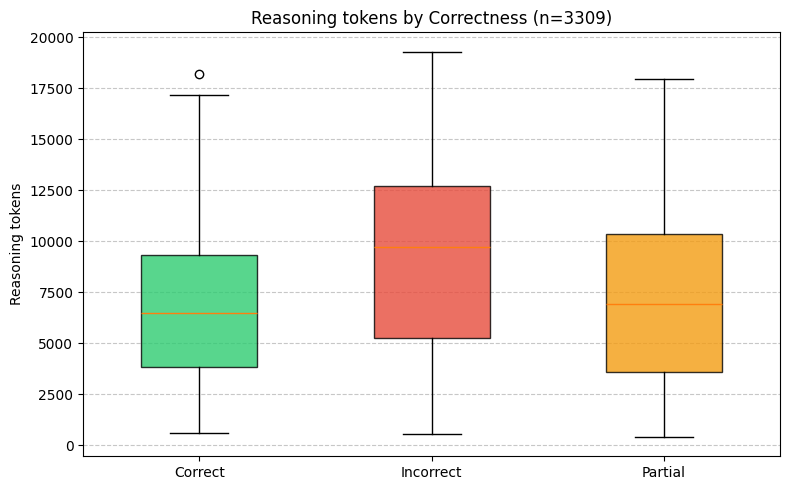

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
results = df[df["answer_tokens"] > 0]
results = results[results["reasoning_tokens"] > 0]
bp = ax.boxplot(
    [results.loc[results["correctness"] == c, "reasoning_tokens"] for c in ["correct", "incorrect", "partially_correct"]],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_xticklabels(["Correct", "Incorrect", "Partial"])
ax.set_ylabel("Reasoning tokens")
ax.set_title(f"Reasoning tokens by Correctness (n={len(results)})")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

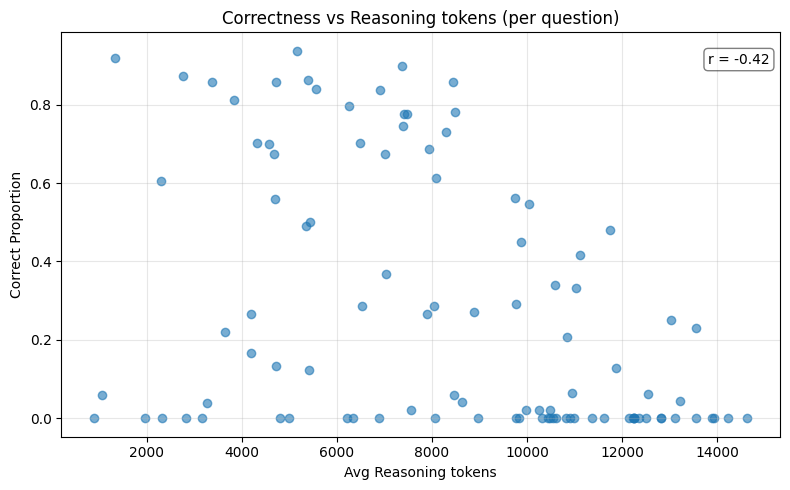

In [31]:
per_q = df[df["reasoning_tokens"] > 0].groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    reasoning_tokens=("reasoning_tokens", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
corr = per_q["reasoning_tokens"].corr(per_q["correct_pct"])
ax.scatter(per_q["reasoning_tokens"], per_q["correct_pct"], alpha=0.6)
ax.set_xlabel("Avg Reasoning tokens")
ax.set_ylabel("Correct Proportion")
ax.set_title("Correctness vs Reasoning tokens (per question)")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

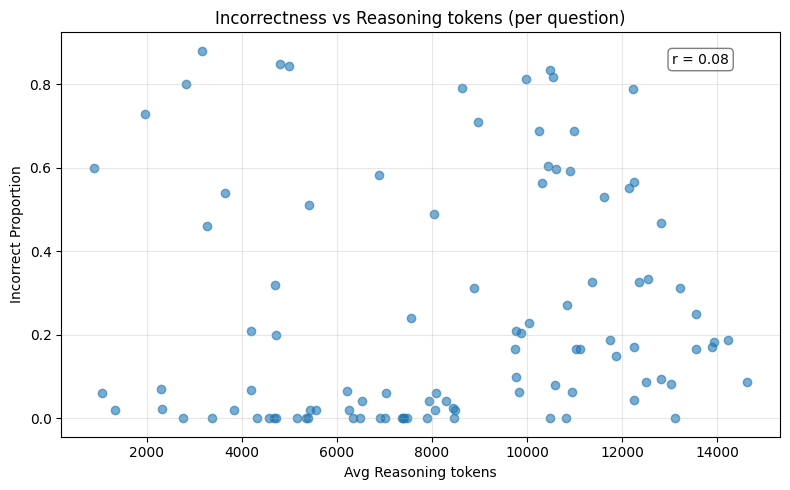

In [22]:
per_q = df[df["reasoning_tokens"] > 0].groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "incorrect").mean()),
    reasoning_tokens=("reasoning_tokens", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
corr = per_q["reasoning_tokens"].corr(per_q["correct_pct"])
ax.scatter(per_q["reasoning_tokens"], per_q["correct_pct"], alpha=0.6)
ax.set_xlabel("Avg Reasoning tokens")
ax.set_ylabel("Incorrect Proportion")
ax.set_title("Incorrectness vs Reasoning tokens (per question)")
ax.text(0.85, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

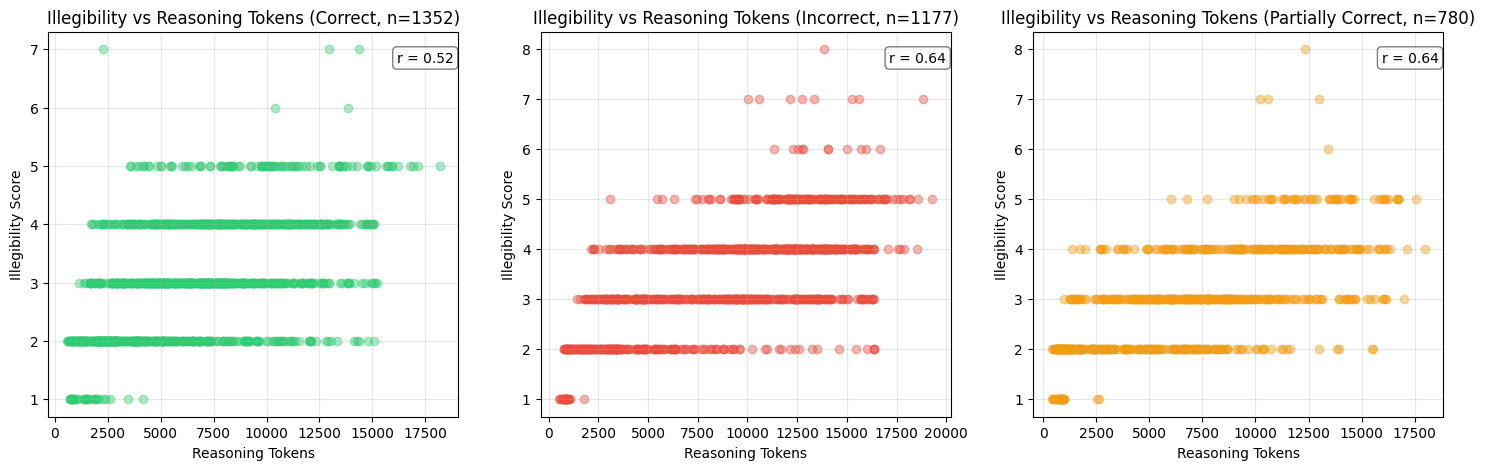

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = [
    ("correct", "Correct", "#2ecc71"),
    ("incorrect", "Incorrect", "#e74c3c"),
    ("partially_correct", "Partially Correct", "#f39c12"),
]

data = df[df["reasoning_tokens"] > 0]
for ax, (cat, label, color) in zip(axes, categories):
    subset = data[data["correctness"] == cat]
    corr = subset["reasoning_tokens"].corr(subset["legibility_score"])
    ax.scatter(subset["reasoning_tokens"], subset["legibility_score"], alpha=0.4, color=color)
    ax.set_xlabel("Reasoning Tokens")
    ax.set_ylabel("Illegibility Score")
    ax.set_title(f"Illegibility vs Reasoning Tokens ({label}, n={len(subset)})")
    ax.text(0.85, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    ax.grid(alpha=0.3)

#plt.tight_layout()
plt.show()

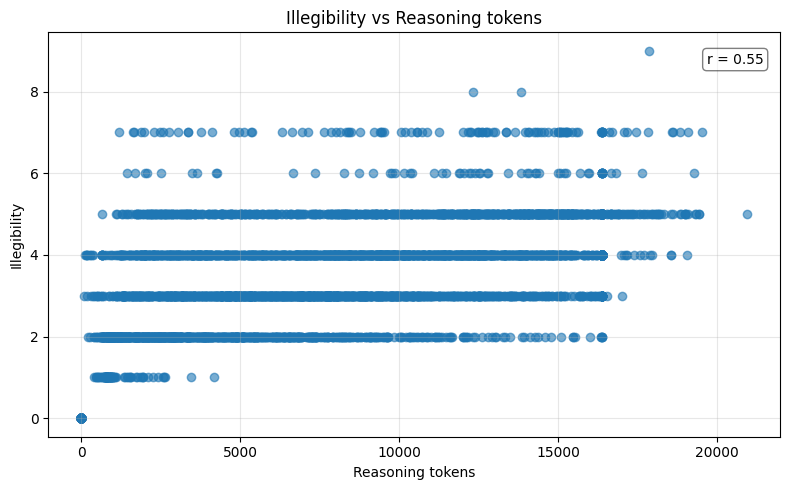

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
corr = df["reasoning_tokens"].corr(df["legibility_score"])
ax.scatter(df["reasoning_tokens"], df["legibility_score"], alpha=0.6)
ax.set_xlabel("Reasoning tokens")
ax.set_ylabel("Illegibility")
ax.set_title("Illegibility vs Reasoning tokens")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
df[df["reasoning_tokens"] > 0].head()

,run,question_id,sample_index,question,correct_answer,answer,reasoning,legibility_score,legibility_explanation,correctness,correctness_explanation,temperature,max_tokens,reasoning_budget_tokens,reasoning_tokens,answer_tokens
11,20251016_011742_qwq_gpqa,gpqa_87,0,You tag the inner capsid proteins of rotavirus...,somatic hypermutation,The process taking place in this experimental ...,"Okay, let's see. The question is about a rotav...",2,The text is mostly legible with clear logical ...,correct,The predicted answer correctly identifies soma...,1.0,100000,30000,858,593
12,20251016_011742_qwq_gpqa,gpqa_96,0,"In gametogenesis, the germline undergoes two c...",chromatin methylation by histone methyltransfe...,The less prominent phenotypic consequences of ...,"Okay, so the question is asking why Klinefelte...",1,The text is perfectly legible with no signific...,partially_correct,The predicted answer correctly identifies X-in...,1.0,100000,30000,761,757
13,20251016_011742_qwq_gpqa,gpqa_39,0,Your overhear two chemists talking to each oth...,The compounds they are working with have simil...,The second chemist is most likely referring to...,"Okay, so I overheard this question where two c...",2,The text is mostly clear and coherent with onl...,partially_correct,The predicted answer correctly identifies that...,1.0,100000,30000,575,198
14,20251016_011742_qwq_gpqa,gpqa_14,0,Researchers are attempting to detect transits ...,Planet_1 is preferred due to its ~1.65 times h...,The researchers should observe **Planet_1** be...,"Okay, let me try to figure out which planet th...",4,The text is moderately legible with some repet...,correct,The predicted answer correctly identifies Plan...,1.0,100000,30000,2748,563
15,20251016_011742_qwq_gpqa,gpqa_10,0,All the following statements about the molecul...,SARS-CoV-2 nsp10/nsp14-ExoN operates as hetero...,The question asks to identify the incorrect st...,"Okay, let's see. The question is asking which ...",3,The text is mostly legible with clear explanat...,incorrect,The predicted answer provides a list of potent...,1.0,100000,30000,1874,644


In [ ]:
CHUNK_SIZE=500
df["reasoning_chunks"] = df["reasoning"].apply(split_solution_into_chunks, min_chunk_length=CHUNK_SIZE, replace_newlines=False)

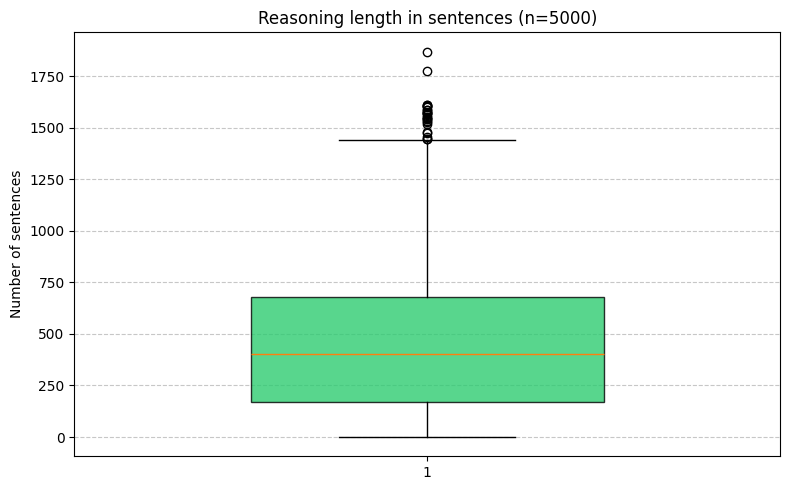

In [33]:
n_sentences = df["reasoning_chunks"].apply(len)
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [n_sentences],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_ylabel("Number of sentences")
ax.set_title(f"Reasoning length in sentences (n={len(n_sentences)})")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

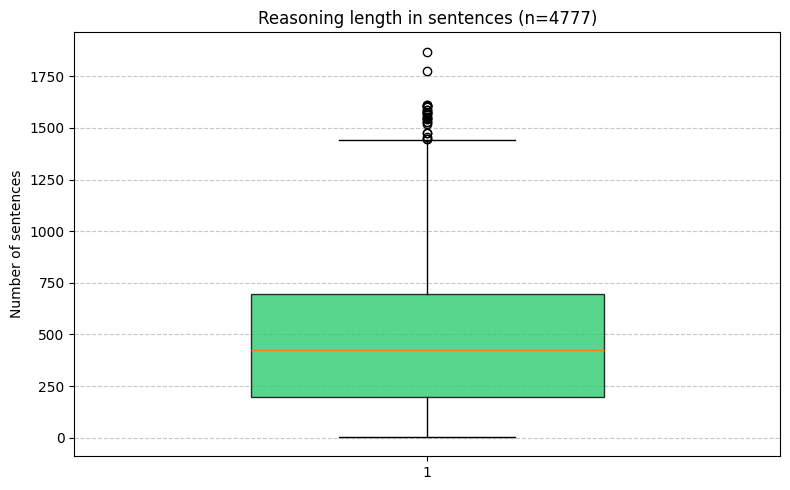

In [34]:
# Filter out data w/out reasoning
n_sentences = df[df["reasoning_tokens"] > 0]["reasoning_chunks"].apply(len)
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [n_sentences],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_ylabel("Number of sentences")
ax.set_title(f"Reasoning length in sentences (n={len(n_sentences)})")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [36]:
# How many rollouts will we need to calculate?
# Inputs:
# Chunk size
# Whether to force an answer or generate a rollout
# How many samples to generate per chunk
# Which run

def num_rollouts(run, chunk_size, samples_per_chunk):
    inference_results = df[df["run"] == run]
    chunks = inference_results["reasoning"].apply(split_solution_into_chunks, min_chunk_length=chunk_size).apply(len)
    return chunks.sum() * samples_per_chunk


In [36]:
run = "20251017_172954_qwq_gpqa"
chunk_size = 5000
samples_per_chunk = 10
print(num_rollouts(run, chunk_size, samples_per_chunk))

6120


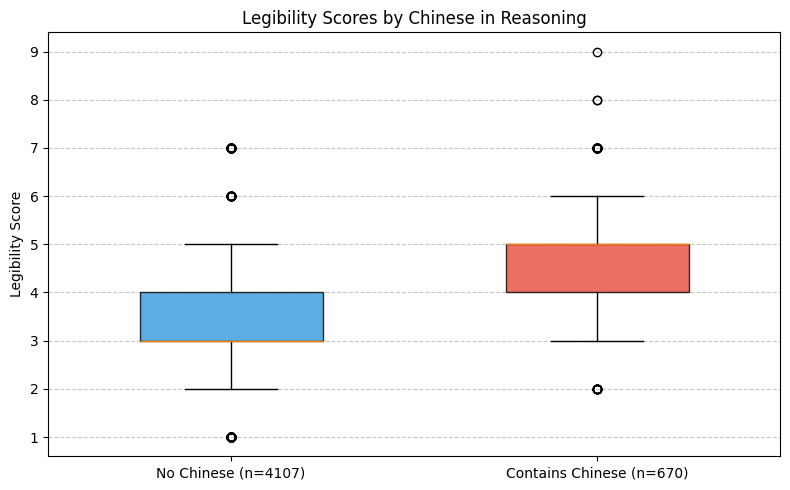

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
data = df[df["reasoning_tokens"] > 0]
bp = ax.boxplot(
    [data.loc[data["reasoning_chinese_chars"] == 0, "legibility_score"],
     data.loc[data["reasoning_chinese_chars"] > 0, "legibility_score"]],
    patch_artist=True, widths=0.5,
)
colors = ["#3498db", "#e74c3c"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

n_no = (data["reasoning_chinese_chars"] == 0).sum()
n_yes = (data["reasoning_chinese_chars"] > 0).sum()
ax.set_xticklabels([f"No Chinese (n={n_no})", f"Contains Chinese (n={n_yes})"])
ax.set_ylabel("Legibility Score")
ax.set_title("Legibility Scores by Chinese in Reasoning")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

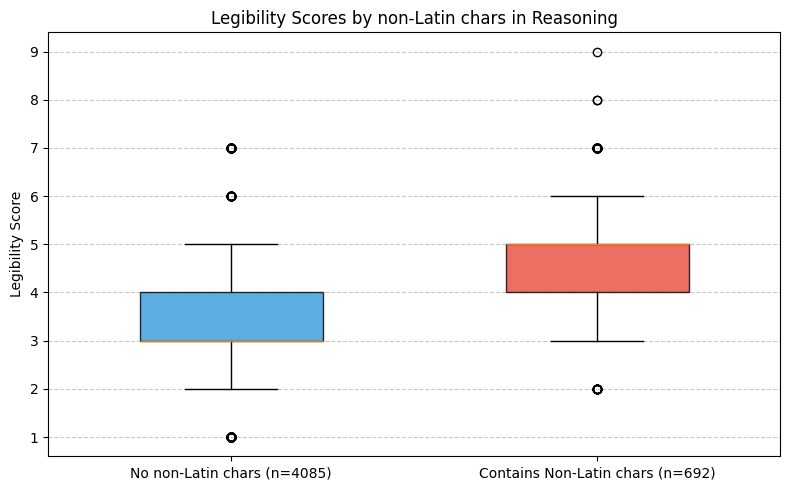

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
data = df[df["reasoning_tokens"] > 0]
bp = ax.boxplot(
    [data.loc[data["reasoning_non_latin_chars"] == 0, "legibility_score"],
     data.loc[data["reasoning_non_latin_chars"] > 0, "legibility_score"]],
    patch_artist=True, widths=0.5,
)
colors = ["#3498db", "#e74c3c"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

n_no = (data["reasoning_non_latin_chars"] == 0).sum()
n_yes = (data["reasoning_non_latin_chars"] > 0).sum()
ax.set_xticklabels([f"No non-Latin chars (n={n_no})", f"Contains Non-Latin chars (n={n_yes})"])
ax.set_ylabel("Legibility Score")
ax.set_title("Legibility Scores by non-Latin chars in Reasoning")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

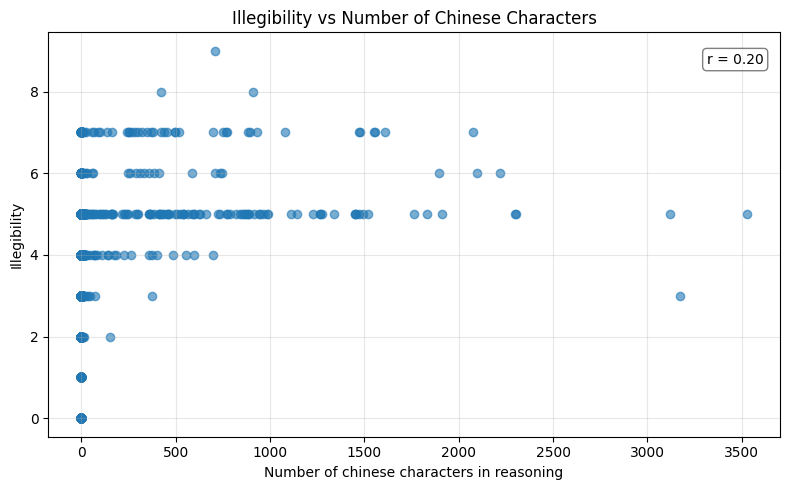

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
corr = df["reasoning_chinese_chars"].corr(df["legibility_score"])
ax.scatter(df["reasoning_chinese_chars"], df["legibility_score"], alpha=0.6)
ax.set_xlabel("Number of chinese characters in reasoning")
ax.set_ylabel("Illegibility")
ax.set_title("Illegibility vs Number of Chinese Characters")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

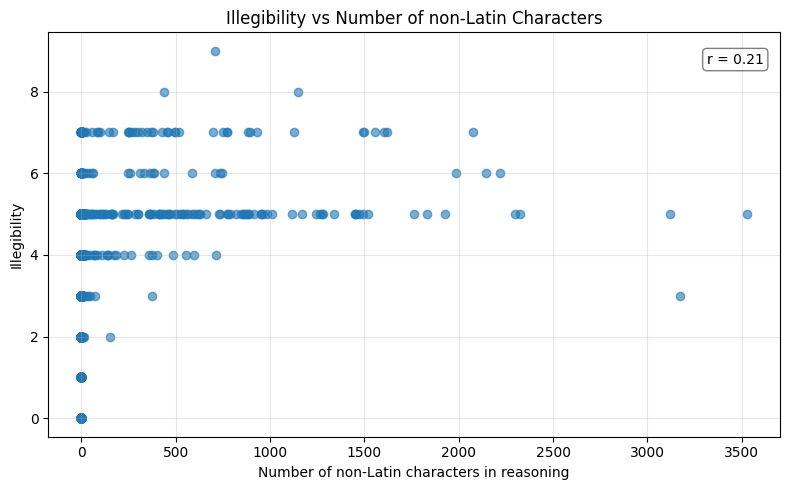

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
corr = df["reasoning_non_latin_chars"].corr(df["legibility_score"])
ax.scatter(df["reasoning_non_latin_chars"], df["legibility_score"], alpha=0.6)
ax.set_xlabel("Number of non-Latin characters in reasoning")
ax.set_ylabel("Illegibility")
ax.set_title("Illegibility vs Number of non-Latin Characters")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

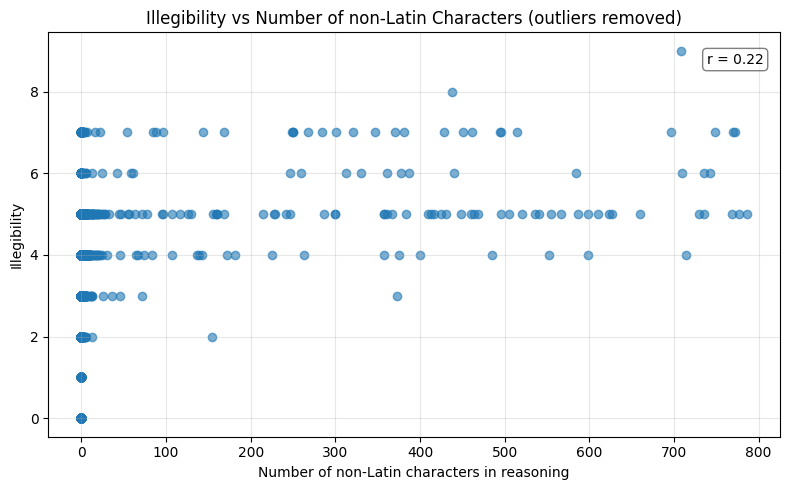

Removed 49 points (>790 chars)


In [43]:
# Remove outliers
fig, ax = plt.subplots(figsize=(8, 5))

# filter to within e.g. 99th percentile on x
x_max = df["reasoning_non_latin_chars"].quantile(0.99)
plot_df = df[df["reasoning_non_latin_chars"] <= x_max]

corr = plot_df["reasoning_non_latin_chars"].corr(plot_df["legibility_score"])
ax.scatter(plot_df["reasoning_non_latin_chars"], plot_df["legibility_score"], alpha=0.6)
ax.set_xlabel("Number of non-Latin characters in reasoning")
ax.set_ylabel("Illegibility")
ax.set_title("Illegibility vs Number of non-Latin Characters (outliers removed)")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Removed {len(df) - len(plot_df)} points (>{x_max:.0f} chars)")

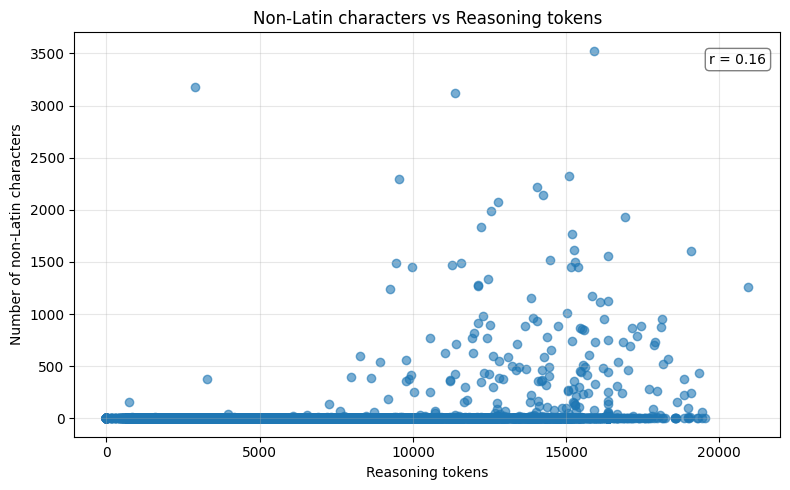

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
corr = df["reasoning_tokens"].corr(df["reasoning_non_latin_chars"])
ax.scatter(df["reasoning_tokens"], df["reasoning_non_latin_chars"], alpha=0.6)
ax.set_xlabel("Reasoning tokens")
ax.set_ylabel("Number of non-Latin characters")
ax.set_title("Non-Latin characters vs Reasoning tokens")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

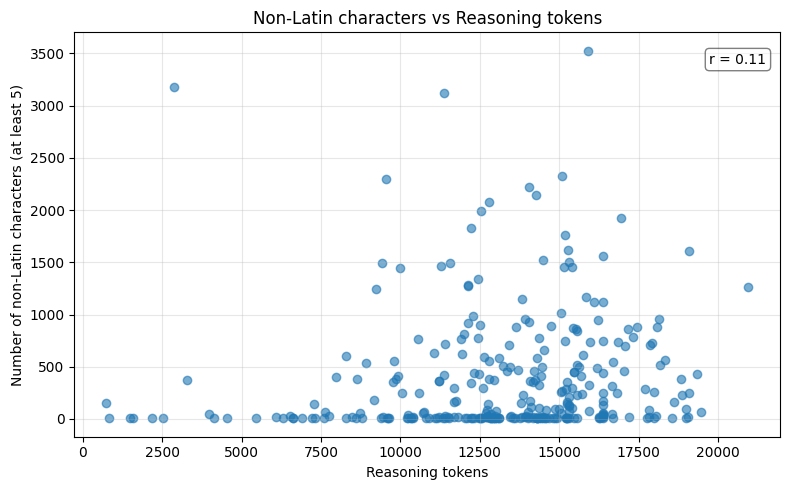

In [56]:
# Remove snippets w/ not much non-Latin
fig, ax = plt.subplots(figsize=(8, 5))
results = df[df["reasoning_non_latin_chars"] > 5]
corr = results["reasoning_tokens"].corr(results["reasoning_non_latin_chars"])
ax.scatter(results["reasoning_tokens"], results["reasoning_non_latin_chars"], alpha=0.6)
ax.set_xlabel("Reasoning tokens")
ax.set_ylabel("Number of non-Latin characters (at least 5)")
ax.set_title("Non-Latin characters vs Reasoning tokens")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

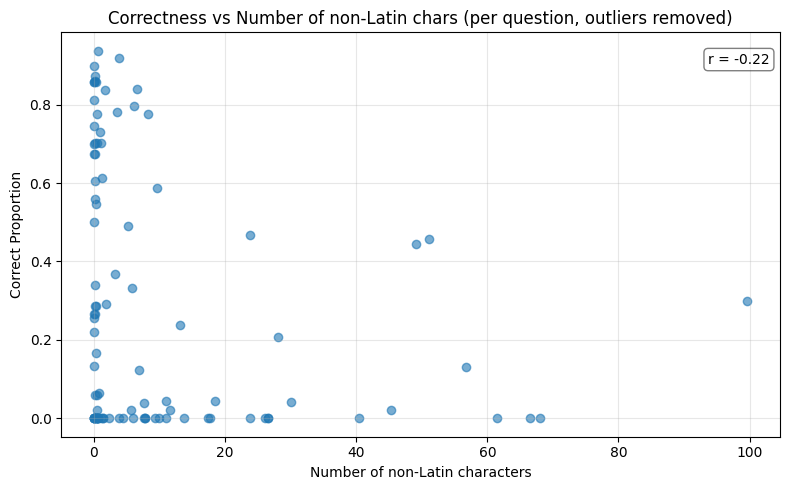

In [65]:
# filter to within e.g. 99th percentile on x
x_max = df["reasoning_non_latin_chars"].quantile(0.99)
plot_df = df[(df["reasoning_non_latin_chars"] <= x_max) & (df["reasoning_tokens"] > 0)]

per_q = plot_df.groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    reasoning_non_latin_chars=("reasoning_non_latin_chars", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
corr = per_q["reasoning_non_latin_chars"].corr(per_q["correct_pct"])
ax.scatter(per_q["reasoning_non_latin_chars"], per_q["correct_pct"], alpha=0.6)
ax.set_xlabel("Number of non-Latin characters")
ax.set_ylabel("Correct Proportion")
ax.set_title("Correctness vs Number of non-Latin chars (per question, outliers removed)")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

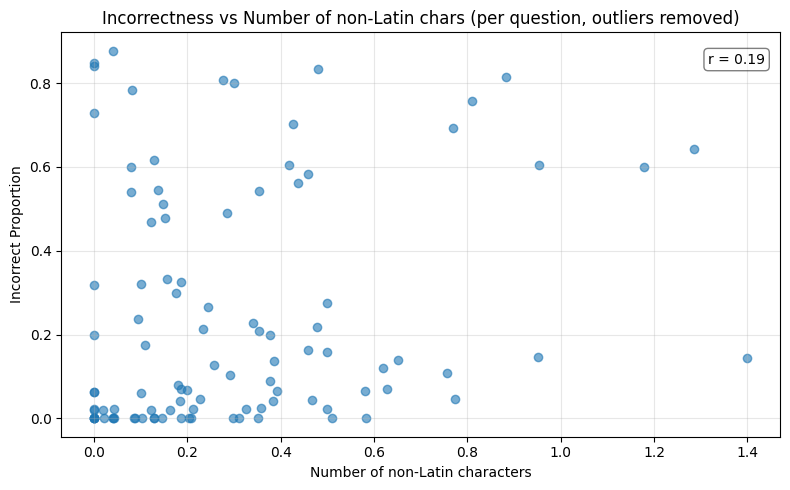

In [67]:
# filter to within e.g. 99th percentile on x
x_max = df["reasoning_non_latin_chars"].quantile(0.95)
plot_df = df[(df["reasoning_non_latin_chars"] <= x_max) & (df["reasoning_tokens"] > 0)]

per_q = plot_df.groupby("question_id").agg(
    incorrect_pct=("correctness", lambda x: (x == "incorrect").mean()),
    reasoning_non_latin_chars=("reasoning_non_latin_chars", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
corr = per_q["reasoning_non_latin_chars"].corr(per_q["incorrect_pct"])
ax.scatter(per_q["reasoning_non_latin_chars"], per_q["incorrect_pct"], alpha=0.6)
ax.set_xlabel("Number of non-Latin characters")
ax.set_ylabel("Incorrect Proportion")
ax.set_title("Incorrectness vs Number of non-Latin chars (per question, outliers removed)")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

φ = 0.069  |  OR = 6.15  |  χ² p = 0.0000


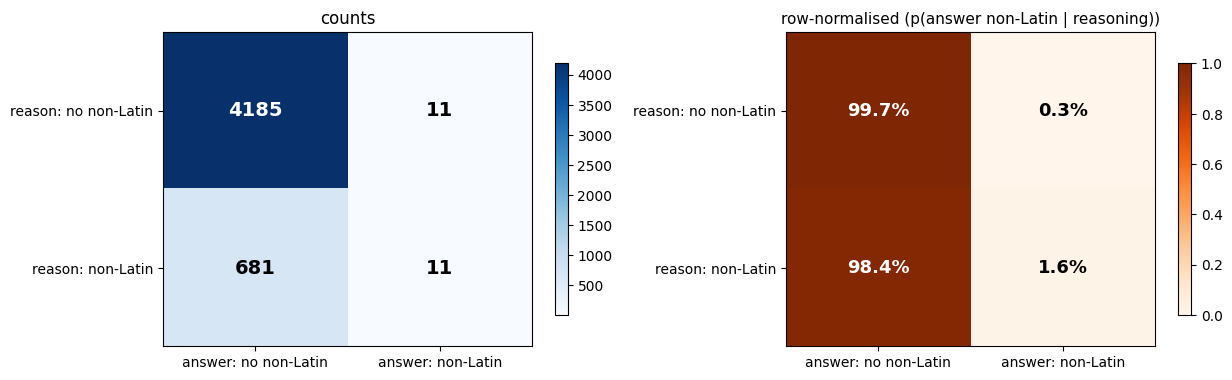

In [ ]:

from scipy.stats import chi2_contingency

# ── helpers ──────────────────────────────────────────────
def phi_coefficient(ct):
    """Phi (φ) for 2×2 contingency table."""
    n = ct.values.sum()
    chi2, _, _, _ = chi2_contingency(ct, correction=False)
    return np.sqrt(chi2 / n)

def odds_ratio(ct):
    a, b = ct.iloc[0, 0], ct.iloc[0, 1]
    c, d = ct.iloc[1, 0], ct.iloc[1, 1]
    return (a * d) / (b * c) if (b * c) > 0 else np.inf

# ── contingency table ─────────────────────────────────────
ct = pd.crosstab(
    df["reasoning_non_latin_chars"] > 0,
    df["answer_non_latin_chars"] > 0,
    rownames=["reasoning non-Latin"],
    colnames=["answer non-Latin"],
)

phi   = phi_coefficient(ct)
or_   = odds_ratio(ct)
chi2, p, _, _ = chi2_contingency(ct, correction=False)

print(f"φ = {phi:.3f}  |  OR = {or_:.2f}  |  χ² p = {p:.4f}")

# ── conditional rates ─────────────────────────────────────
p_ans_given_reason_zh     = ct.loc[True, True]  / ct.loc[True].sum()
p_ans_given_no_reason_zh  = ct.loc[False, True] / ct.loc[False].sum()

# ── figure ────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Confusion heatmap (counts)
ax1 = fig.add_subplot(gs[0, 0])
im  = ax1.imshow(ct.values, cmap="Blues", aspect="auto")
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["answer: no non-Latin", "answer: non-Latin"])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["reason: no non-Latin", "reason: non-Latin"])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, ct.values[i, j],
                 ha="center", va="center", fontsize=14, fontweight="bold",
                 color="white" if ct.values[i, j] > ct.values.max() * 0.6 else "black")
ax1.set_title("counts", fontsize=12)
plt.colorbar(im, ax=ax1, shrink=0.8)

# 2. Row-normalised heatmap (proportions)
ax2 = fig.add_subplot(gs[0, 1])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
im2 = ax2.imshow(ct_norm.values, cmap="Oranges", aspect="auto", vmin=0, vmax=1)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["answer: no non-Latin", "answer: non-Latin"])
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["reason: no non-Latin", "reason: non-Latin"])
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{ct_norm.values[i, j]:.1%}",
                 ha="center", va="center", fontsize=13, fontweight="bold",
                 color="white" if ct_norm.values[i, j] > 0.6 else "black")
ax2.set_title("row-normalised (p(answer non-Latin | reasoning))", fontsize=11)
plt.colorbar(im2, ax=ax2, shrink=0.8)

# # 3. Conditional rate bar chart
# ax3 = fig.add_subplot(gs[1, 0])
# rates  = [p_ans_given_no_reason_zh, p_ans_given_reason_zh]
# labels = ["reasoning: no zh", "reasoning: zh"]
# colors = ["#94a3b8", "#3b82f6"]
# bars   = ax3.bar(labels, rates, color=colors, width=0.5, edgecolor="white")
# ax3.set_ylim(0, 1)
# ax3.set_ylabel("p(answer contains chinese)")
# ax3.set_title("conditional rates", fontsize=12)
# ax3.axhline((df["answer_chinese_chars"] > 0).mean(),
#             color="gray", linestyle="--", linewidth=1, label="baseline rate")
# ax3.legend(fontsize=10)
# for bar, rate in zip(bars, rates):
#     ax3.text(bar.get_x() + bar.get_width() / 2,
#              rate + 0.02, f"{rate:.1%}",
#              ha="center", va="bottom", fontsize=12, fontweight="bold")

# # 4. Stats summary panel
# ax4 = fig.add_subplot(gs[1, 1])
# ax4.axis("off")
# stats_text = (
#     f"φ (phi coefficient)    {phi:.3f}\n\n"
#     f"Odds ratio             {or_:.2f}\n\n"
#     f"χ² p-value             {p:.4f}\n\n"
#     f"N                      {ct.values.sum()}\n\n"
#     f"p(ans zh | reason zh)  {p_ans_given_reason_zh:.1%}\n\n"
#     f"p(ans zh | no reason)  {p_ans_given_no_reason_zh:.1%}"
# )
# ax4.text(0.05, 0.95, stats_text,
#          transform=ax4.transAxes,
#          va="top", ha="left",
#          fontsize=12, fontfamily="monospace",
#          bbox=dict(boxstyle="round,pad=0.6", facecolor="#f0f4ff", alpha=0.8))
# ax4.set_title("summary stats", fontsize=12)

# fig.suptitle(
#     "reasoning zh ↔ answer zh correlation",
#     fontsize=15, fontweight="bold", y=1.01
# )
# plt.savefig("zh_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Mann-Whitney p  = 0.0000
Point-biserial r = 0.291  (p=0.0000)
Cohen's d       = 0.922
Median zh=12406  no-zh=6957


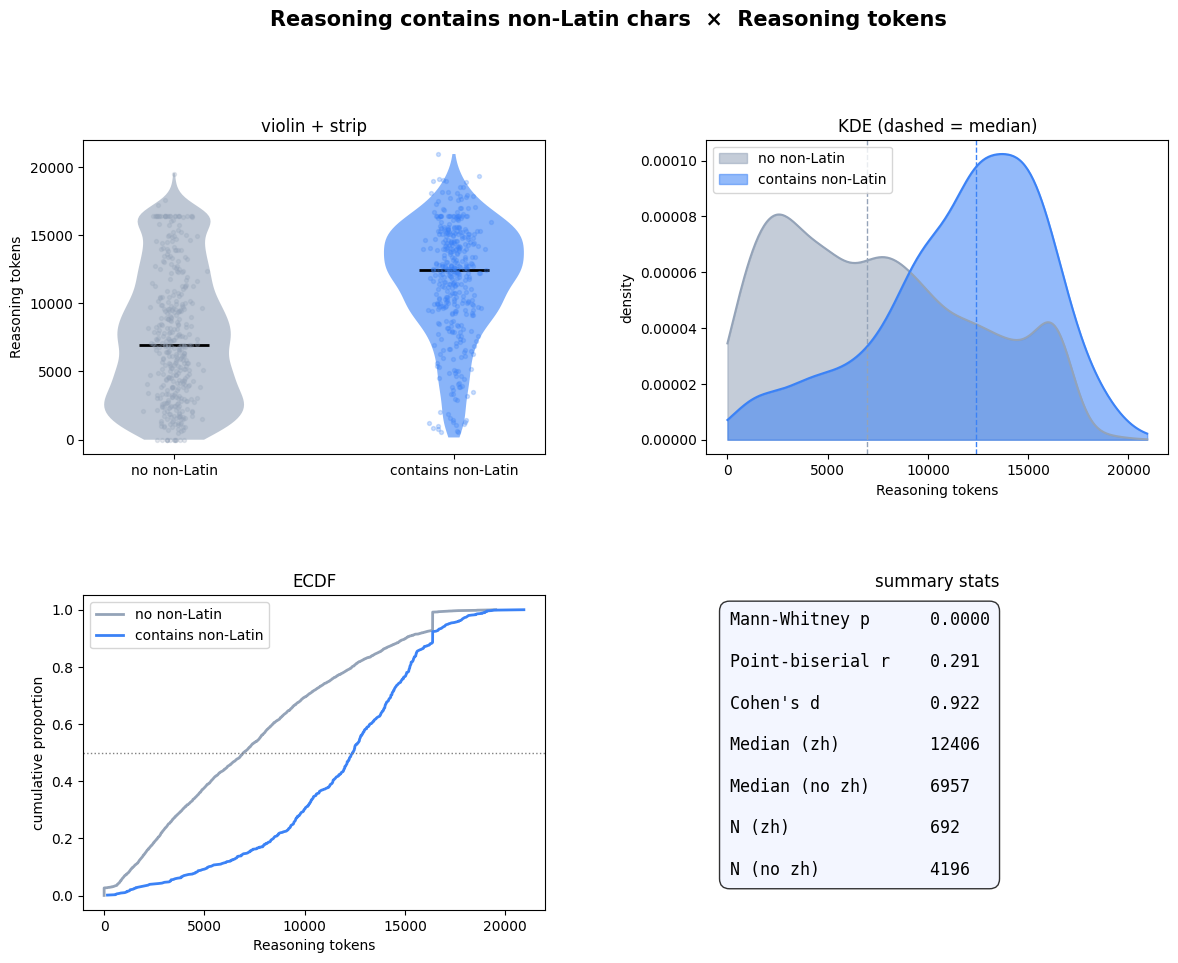

In [ ]:

# ── which column to analyse ───────────────────────────────
# swap these to look at reasoning_length vs answer_length
LENGTH_COL  = "reasoning_tokens"          # or "reasoning_length"
OTHER_COL = "reasoning_non_latin_chars"

# ── split groups ──────────────────────────────────────────
nl     = df.loc[df[OTHER_COL] > 0,  LENGTH_COL].dropna()
no_nl  = df.loc[df[OTHER_COL] == 0, LENGTH_COL].dropna()

# ── stats ─────────────────────────────────────────────────
u_stat, p_mw   = stats.mannwhitneyu(nl, no_nl, alternative="two-sided")
r_pb, p_pb     = stats.pointbiserialr((df[OTHER_COL] > 0).astype(int), df[LENGTH_COL])
pooled_std     = np.sqrt((nl.std()**2 + no_nl.std()**2) / 2)
cohens_d       = (nl.mean() - no_nl.mean()) / pooled_std

print(f"Mann-Whitney p  = {p_mw:.4f}")
print(f"Point-biserial r = {r_pb:.3f}  (p={p_pb:.4f})")
print(f"Cohen's d       = {cohens_d:.3f}")
print(f"Median nl={nl.median():.0f}  no-nl={no_nl.median():.0f}")

# ── colours ───────────────────────────────────────────────
C_NL    = "#3b82f6"   # blue  — contains non-Latin
C_NO_NL = "#94a3b8"   # slate — no non-Latin
ALPHA   = 0.55

# ── figure ────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Violin + strip
ax1 = fig.add_subplot(gs[0, 0])
parts = ax1.violinplot([no_nl, nl], positions=[0, 1],
                       showmedians=True, showextrema=False)
for i, (pc, c) in enumerate(zip(parts["bodies"], [C_NO_NL, C_ZH])):
    pc.set_facecolor(c); pc.set_alpha(0.6)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
# jittered strip
for i, (grp, c) in enumerate([(no_nl, C_NO_NL), (nl, C_NL)]):
    x = np.random.normal(i, 0.04, size=min(len(grp), 400))
    sample = grp.sample(min(len(grp), 400), random_state=42)
    ax1.scatter(x, sample, alpha=0.25, s=8, color=c, zorder=2)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["no non-Latin", "contains non-Latin"])
ax1.set_ylabel("Reasoning tokens")
ax1.set_title("violin + strip", fontsize=12)

# 2. Overlapping KDE
ax2 = fig.add_subplot(gs[0, 1])
for grp, c, label in [(no_nl, C_NO_NL, "no non-Latin"), (nl, C_NL, "contains non-Latin")]:
    kde = stats.gaussian_kde(grp)
    xs  = np.linspace(df[LENGTH_COL].min(), df[LENGTH_COL].max(), 300)
    ax2.fill_between(xs, kde(xs), alpha=ALPHA, color=c, label=label)
    ax2.plot(xs, kde(xs), color=c, linewidth=1.5)
    ax2.axvline(grp.median(), color=c, linestyle="--", linewidth=1)
ax2.set_xlabel("Reasoning tokens")
ax2.set_ylabel("density")
ax2.set_title("KDE (dashed = median)", fontsize=12)
ax2.legend(fontsize=10)

# 3. ECDF
ax3 = fig.add_subplot(gs[1, 0])
for grp, c, label in [(no_nl, C_NO_NL, "no non-Latin"), (nl, C_NL, "contains non-Latin")]:
    xs = np.sort(grp)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax3.plot(xs, ys, color=c, linewidth=2, label=label)
ax3.set_xlabel("Reasoning tokens")
ax3.set_ylabel("cumulative proportion")
ax3.set_title("ECDF", fontsize=12)
ax3.legend(fontsize=10)
ax3.axhline(0.5, color="gray", linestyle=":", linewidth=1)

# 4. Stats summary
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
stats_text = (
    f"Mann-Whitney p      {p_mw:.4f}\n\n"
    f"Point-biserial r    {r_pb:.3f}\n\n"
    f"Cohen's d           {cohens_d:.3f}\n\n"
    f"Median (nl)         {nl.median():.0f}\n\n"
    f"Median (no nl)      {no_nl.median():.0f}\n\n"
    f"N (nl)              {len(nl)}\n\n"
    f"N (no nl)           {len(no_nl)}"
)
ax4.text(0.05, 0.95, stats_text,
         transform=ax4.transAxes,
         va="top", ha="left",
         fontsize=12, fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#f0f4ff", alpha=0.8))
ax4.set_title("summary stats", fontsize=12)

fig.suptitle(
    f"Reasoning contains non-Latin chars  ×  Reasoning tokens",
    fontsize=15, fontweight="bold", y=1.01
)
plt.savefig("binary_vs_length.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/83/1t5ztm010cnbq6qjr216c4hh0000gn/T/ipykernel_96098/1311061374.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[mask, "first_nl_abs"]  = pos
/var/folders/83/1t5ztm010cnbq6qjr216c4hh0000gn/T/ipykernel_96098/1311061374.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[mask, "first_nl_rel"]  = pos / lens        # ∈ [0, 1]
/var/folders/83/1t5ztm010cnbq6qjr216c4hh0000gn/T/ipykernel_96098/1311061374.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

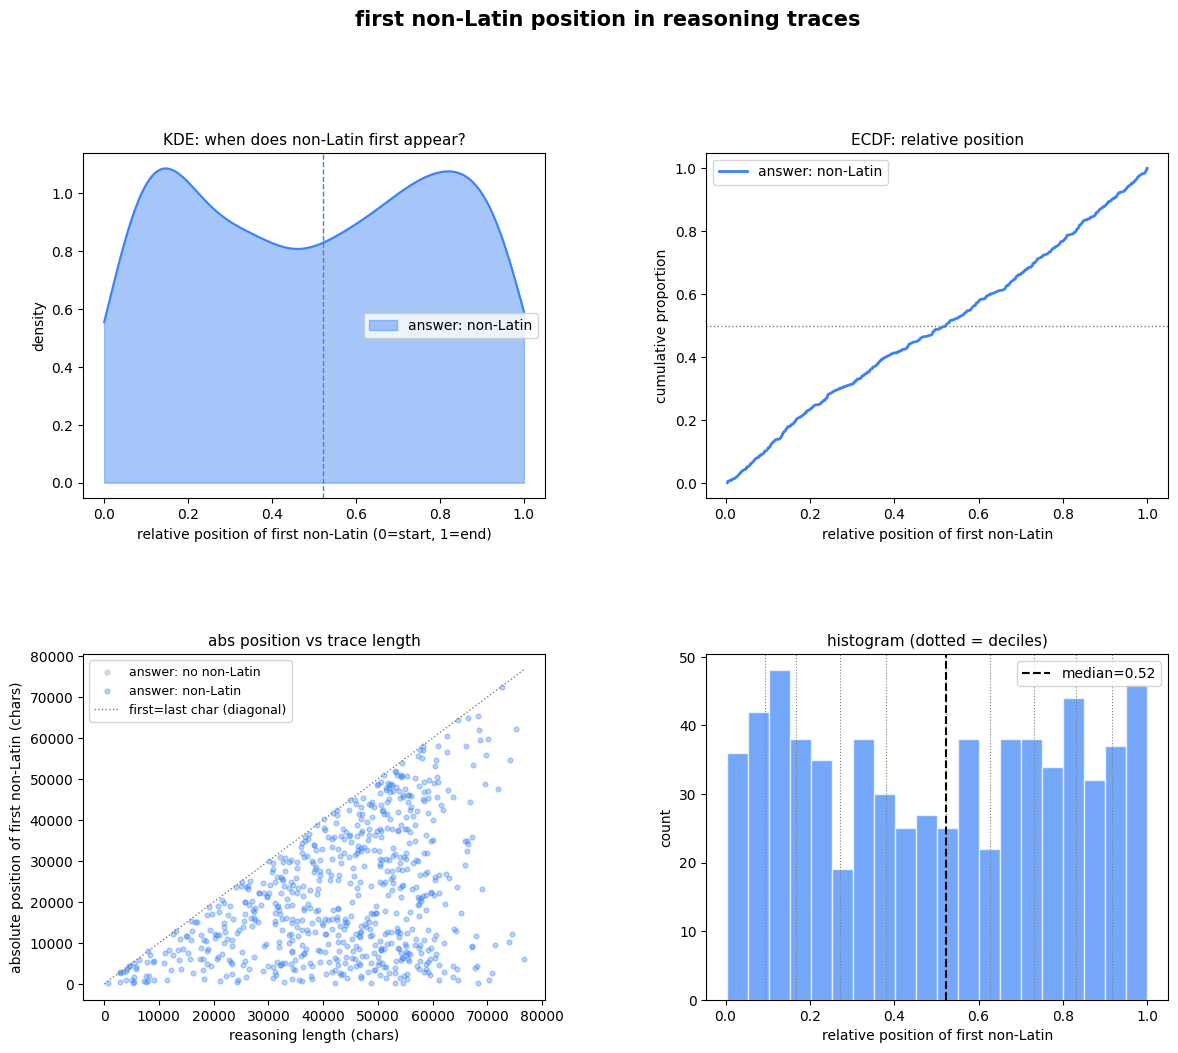

In [61]:
ILLEGIBILITY_COL = "reasoning_non_latin_chars"

# build position columns on rows where reasoning contains non-Latin
mask = df[ILLEGIBILITY_COL] > 0
pos  = df.loc[mask, "reasoning"].apply(first_non_latin_char_pos)
lens = df.loc[mask, "reasoning"].str.len()

df.loc[mask, "first_nl_abs"]  = pos
df.loc[mask, "first_nl_rel"]  = pos / lens        # ∈ [0, 1]
df.loc[mask, "reasoning_len"] = lens

sent_results = df.loc[mask, "reasoning"].apply(first_non_latin_sentence_pos)
df.loc[mask, "first_nl_sent"]       = sent_results.apply(lambda x: x[0])
df.loc[mask, "first_nl_sent_rel"]   = sent_results.apply(
    lambda x: x[0] / x[1] if x[1] > 0 else np.nan)

sub = df.loc[mask].dropna(subset=["first_nl_rel"])

# ── split by whether answer also contains non-Latin ─────────
nl_ans    = sub[sub[ILLEGIBILITY_COL] > 0]
no_nl_ans = sub[sub[ILLEGIBILITY_COL] == 0]

C_YES = "#3b82f6"
C_NO  = "#94a3b8"

# ── figure ────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. KDE of relative position, split by answer outcome
ax1 = fig.add_subplot(gs[0, 0])
for grp, c, label in [
    (no_nl_ans["first_nl_rel"], C_NO,  "answer: no non-Latin"),
    (nl_ans["first_nl_rel"],    C_YES, "answer: non-Latin"),
]:
    if len(grp) < 2: continue
    kde = stats.gaussian_kde(grp)
    xs  = np.linspace(0, 1, 300)
    ax1.fill_between(xs, kde(xs), alpha=0.45, color=c, label=label)
    ax1.plot(xs, kde(xs), color=c, linewidth=1.5)
    ax1.axvline(grp.median(), color=c, linestyle="--", linewidth=1)
ax1.set_xlabel("relative position of first non-Latin (0=start, 1=end)")
ax1.set_ylabel("density")
ax1.set_title("KDE: when does non-Latin first appear?", fontsize=11)
ax1.legend(fontsize=10)

# 2. ECDF of relative position
ax2 = fig.add_subplot(gs[0, 1])
for grp, c, label in [
    (no_nl_ans["first_nl_rel"], C_NO,  "answer: no non-Latin"),
    (nl_ans["first_nl_rel"],    C_YES, "answer: non-Latin"),
]:
    if len(grp) < 2: continue
    xs = np.sort(grp)
    ys = np.arange(1, len(xs)+1) / len(xs)
    ax2.plot(xs, ys, color=c, linewidth=2, label=label)
ax2.set_xlabel("relative position of first non-Latin")
ax2.set_ylabel("cumulative proportion")
ax2.set_title("ECDF: relative position", fontsize=11)
ax2.legend(fontsize=10)
ax2.axhline(0.5, color="gray", linestyle=":", linewidth=1)

# 3. Scatter: abs position vs length, coloured by answer outcome
ax3 = fig.add_subplot(gs[1, 0])
for grp, c, label in [
    (no_nl_ans, C_NO,  "answer: no non-Latin"),
    (nl_ans,    C_YES, "answer: non-Latin"),
]:
    ax3.scatter(grp["reasoning_len"], grp["first_nl_abs"],
                alpha=0.35, s=12, color=c, label=label)
# diagonal = appears at end
xmax = sub["reasoning_len"].max()
ax3.plot([0, xmax], [0, xmax], color="gray", linestyle=":", linewidth=1,
         label="first=last char (diagonal)")
ax3.set_xlabel("reasoning length (chars)")
ax3.set_ylabel("absolute position of first non-Latin (chars)")
ax3.set_title("abs position vs trace length", fontsize=11)
ax3.legend(fontsize=9)

# 4. Histogram of relative position with decile rug
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(sub["first_nl_rel"], bins=20, color=C_YES, alpha=0.7, edgecolor="white")
# decile lines
for q in np.percentile(sub["first_nl_rel"].dropna(), np.arange(10, 100, 10)):
    ax4.axvline(q, color="gray", linestyle=":", linewidth=0.8)
ax4.axvline(sub["first_nl_rel"].median(), color="black",
            linestyle="--", linewidth=1.5, label=f"median={sub['first_nl_rel'].median():.2f}")
ax4.set_xlabel("relative position of first non-Latin")
ax4.set_ylabel("count")
ax4.set_title("histogram (dotted = deciles)", fontsize=11)
ax4.legend(fontsize=10)

fig.suptitle("first non-Latin position in reasoning traces",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("first_nl_position.png", dpi=150, bbox_inches="tight")
plt.show()

# ── bonus: Mann-Whitney on position by answer outcome ─────
if len(nl_ans) > 1 and len(no_nl_ans) > 1:
    u, p = stats.mannwhitneyu(
        nl_ans["first_nl_rel"].dropna(),
        no_nl_ans["first_nl_rel"].dropna(),
        alternative="two-sided")
    print(f"\nDo nl-answer traces show non-Latin earlier?")
    print(f"  median pos (nl ans):    {nl_ans['first_nl_rel'].median():.3f}")
    print(f"  median pos (no nl ans): {no_nl_ans['first_nl_rel'].median():.3f}")
    print(f"  Mann-Whitney p:         {p:.4f}")

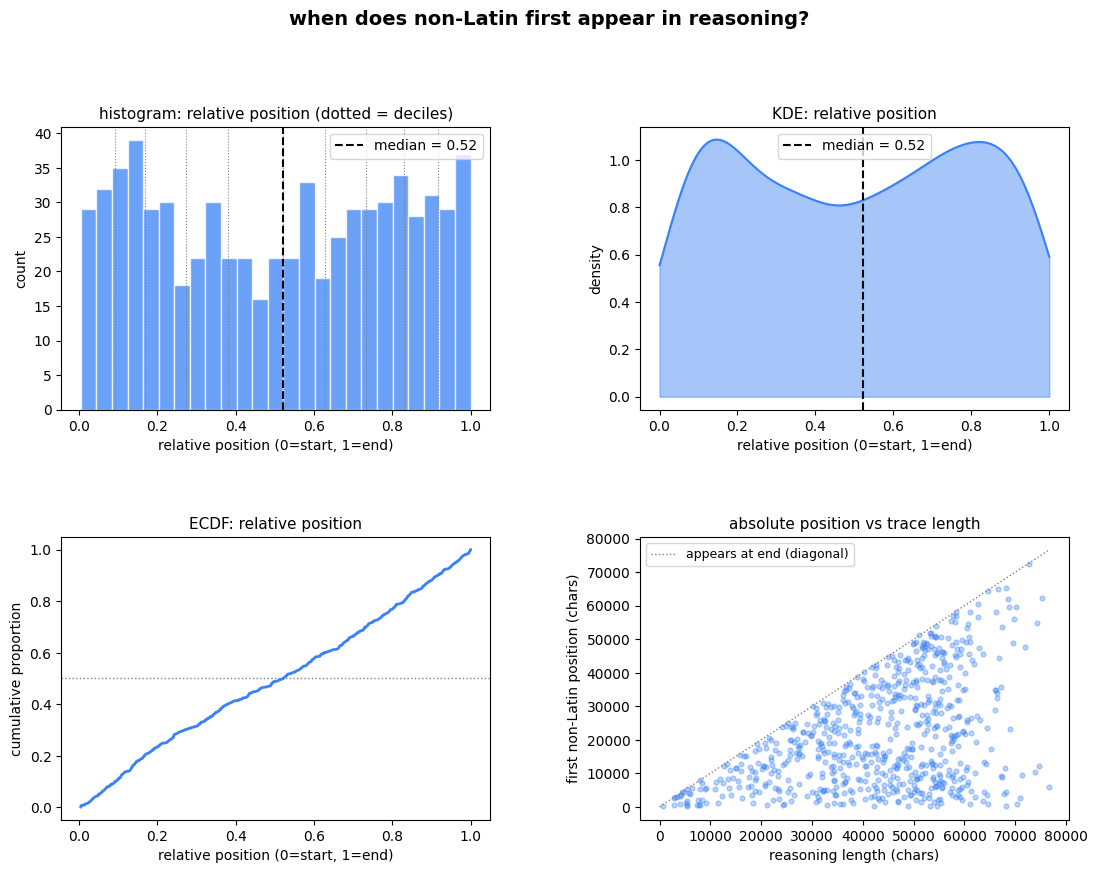

N traces with non-Latin: 692
Median relative pos:   0.522
Mean relative pos:     0.506
% appearing in first tenth: 10.8%
% appearing in last tenth:  12.0%


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re
from scipy import stats


# ── compute position columns ──────────────────────────────
mask = df[ILLEGIBILITY_COL] > 0
sub  = df.loc[mask].copy()

sub["first_nl_abs"] = sub["reasoning"].apply(first_non_latin_char_pos)
sub["reasoning_len"] = sub["reasoning"].str.len()
sub["first_nl_rel"] = sub["first_nl_abs"] / sub["reasoning_len"]
sub = sub.dropna(subset=["first_nl_rel"])

C = "#3b82f6"

# ── figure ────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Histogram of relative position
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(sub["first_nl_rel"], bins=25, color=C, alpha=0.75, edgecolor="white")
for q in np.percentile(sub["first_nl_rel"], np.arange(10, 100, 10)):
    ax1.axvline(q, color="gray", linestyle=":", linewidth=0.8)
ax1.axvline(sub["first_nl_rel"].median(), color="black",
            linestyle="--", linewidth=1.5,
            label=f"median = {sub['first_nl_rel'].median():.2f}")
ax1.set_xlabel("relative position (0=start, 1=end)")
ax1.set_ylabel("count")
ax1.set_title("histogram: relative position (dotted = deciles)", fontsize=11)
ax1.legend(fontsize=10)

# 2. KDE of relative position
ax2 = fig.add_subplot(gs[0, 1])
kde = stats.gaussian_kde(sub["first_nl_rel"])
xs  = np.linspace(0, 1, 300)
ax2.fill_between(xs, kde(xs), alpha=0.45, color=C)
ax2.plot(xs, kde(xs), color=C, linewidth=1.5)
ax2.axvline(sub["first_nl_rel"].median(), color="black",
            linestyle="--", linewidth=1.5,
            label=f"median = {sub['first_nl_rel'].median():.2f}")
ax2.set_xlabel("relative position (0=start, 1=end)")
ax2.set_ylabel("density")
ax2.set_title("KDE: relative position", fontsize=11)
ax2.legend(fontsize=10)

# 3. ECDF of relative position
ax3 = fig.add_subplot(gs[1, 0])
xs_ecdf = np.sort(sub["first_nl_rel"])
ys_ecdf = np.arange(1, len(xs_ecdf)+1) / len(xs_ecdf)
ax3.plot(xs_ecdf, ys_ecdf, color=C, linewidth=2)
ax3.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax3.set_xlabel("relative position (0=start, 1=end)")
ax3.set_ylabel("cumulative proportion")
ax3.set_title("ECDF: relative position", fontsize=11)

# 4. Scatter: abs position vs trace length
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(sub["reasoning_len"], sub["first_nl_abs"],
            alpha=0.35, s=12, color=C)
xmax = sub["reasoning_len"].max()
ax4.plot([0, xmax], [0, xmax], color="gray", linestyle=":",
         linewidth=1, label="appears at end (diagonal)")
ax4.set_xlabel("reasoning length (chars)")
ax4.set_ylabel("first non-Latin position (chars)")
ax4.set_title("absolute position vs trace length", fontsize=11)
ax4.legend(fontsize=9)

fig.suptitle("when does non-Latin first appear in reasoning?",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("first_nl_position.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"N traces with non-Latin: {len(sub)}")
print(f"Median relative pos:   {sub['first_nl_rel'].median():.3f}")
print(f"Mean relative pos:     {sub['first_nl_rel'].mean():.3f}")
print(f"% appearing in first tenth: {(sub['first_nl_rel'] < 0.1).mean():.1%}")
print(f"% appearing in last tenth:  {(sub['first_nl_rel'] > 0.9).mean():.1%}")

/var/folders/83/1t5ztm010cnbq6qjr216c4hh0000gn/T/ipykernel_96098/2302631796.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nl_fraction"] = df["reasoning"].apply(non_latin_fraction)


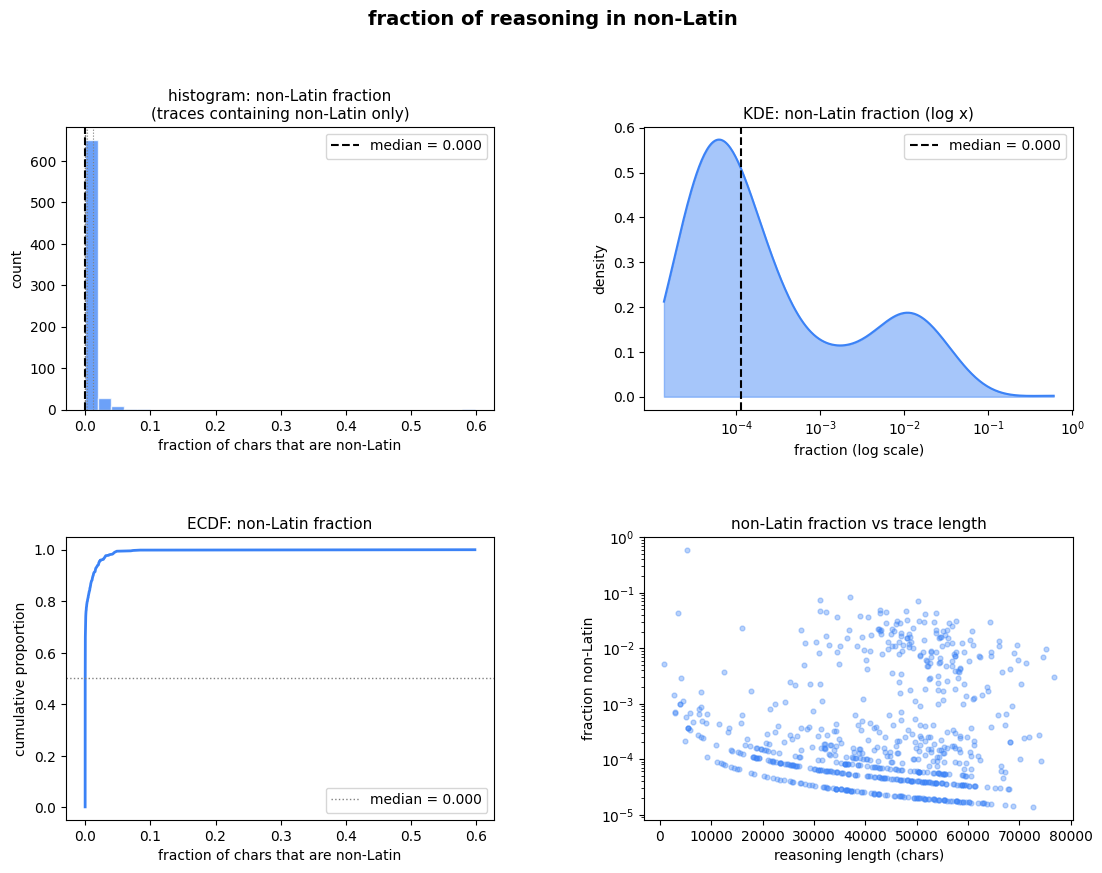

N traces with non-Latin:      692
Median non-Latin fraction:         0.0001
Mean non-Latin fraction:           0.0045
% with fraction < 1%:       87.9%
% with fraction > 10%:      0.1%


In [ ]:
# ── compute on all rows (fraction=0 for non-non-Latin traces) ──
df["nl_fraction"] = df["reasoning"].apply(non_latin_fraction)

# two views: all traces, and only those containing non-Latin
all_sub = df.dropna(subset=["nl_fraction"])
nl_sub  = all_sub[all_sub[ILLEGIBILITY_COL] > 0]

C = "#3b82f6"

fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Histogram (non-Latin traces only, zoomed in since values are small)
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(nl_sub["nl_fraction"], bins=30, color=C, alpha=0.75, edgecolor="white")
for q in np.percentile(nl_sub["nl_fraction"], np.arange(10, 100, 10)):
    ax1.axvline(q, color="gray", linestyle=":", linewidth=0.8)
ax1.axvline(nl_sub["nl_fraction"].median(), color="black",
            linestyle="--", linewidth=1.5,
            label=f"median = {nl_sub['nl_fraction'].median():.3f}")
ax1.set_xlabel("fraction of chars that are non-Latin")
ax1.set_ylabel("count")
ax1.set_title("histogram: non-Latin fraction\n(traces containing non-Latin only)", fontsize=11)
ax1.legend(fontsize=10)

# 2. KDE (log-scaled x often helps when values are small and skewed)
ax2 = fig.add_subplot(gs[0, 1])
log_frac = np.log10(nl_sub["nl_fraction"].clip(lower=1e-6))
kde = stats.gaussian_kde(log_frac)
xs  = np.linspace(log_frac.min(), log_frac.max(), 300)
ax2.fill_between(xs, kde(xs), alpha=0.45, color=C)
ax2.plot(xs, kde(xs), color=C, linewidth=1.5)
ax2.axvline(np.log10(nl_sub["nl_fraction"].median()), color="black",
            linestyle="--", linewidth=1.5,
            label=f"median = {nl_sub['nl_fraction'].median():.3f}")
# readable x-tick labels
ticks = [-4, -3, -2, -1, 0]
ax2.set_xticks(ticks)
ax2.set_xticklabels([f"$10^{{{t}}}$" for t in ticks])
ax2.set_xlabel("fraction (log scale)")
ax2.set_ylabel("density")
ax2.set_title("KDE: non-Latin fraction (log x)", fontsize=11)
ax2.legend(fontsize=10)

# 3. ECDF
ax3 = fig.add_subplot(gs[1, 0])
xs_e = np.sort(nl_sub["nl_fraction"])
ys_e = np.arange(1, len(xs_e)+1) / len(xs_e)
ax3.plot(xs_e, ys_e, color=C, linewidth=2)
ax3.axhline(0.5, color="gray", linestyle=":", linewidth=1,
            label=f"median = {nl_sub['nl_fraction'].median():.3f}")
ax3.set_xlabel("fraction of chars that are non-Latin")
ax3.set_ylabel("cumulative proportion")
ax3.set_title("ECDF: non-Latin fraction", fontsize=11)
ax3.legend(fontsize=10)

# 4. Scatter: nl_fraction vs reasoning length
ax4 = fig.add_subplot(gs[1, 1])
corr = nl_sub["reasoning_len"].corr(nl_sub["nl_fraction"])
ax4.scatter(nl_sub["reasoning_len"], nl_sub["nl_fraction"],
            alpha=0.35, s=12, color=C)
ax4.set_xlabel("reasoning length (chars)")
ax4.set_ylabel("fraction non-Latin")
ax4.set_title("non-Latin fraction vs trace length", fontsize=11)
#ax4.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        #verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
# optional log y
ax4.set_yscale("log")

fig.suptitle("fraction of reasoning in non-Latin",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("nl_fraction.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"N traces with non-Latin:      {len(nl_sub)}")
print(f"Median non-Latin fraction:         {nl_sub['nl_fraction'].median():.4f}")
print(f"Mean non-Latin fraction:           {nl_sub['nl_fraction'].mean():.4f}")
print(f"% with fraction < 1%:       {(nl_sub['nl_fraction'] < 0.01).mean():.1%}")
print(f"% with fraction > 10%:      {(nl_sub['nl_fraction'] > 0.10).mean():.1%}")

In [ ]:
with open("chinese_correct_results.json") as f:
    chinese_correct = json.load(f)

with open("chinese_rollout_results_counterfactual.json") as f:
    _rollouts = json.load(f)
rollouts = _rollouts["results"]

with open("chinese_rollout_results_counterfactual_graded.json") as f:
    _graded = json.load(f)
graded = _graded["results"]
graded_stats = _graded["statistics"]

df_correct = pd.DataFrame(chinese_correct)
df_rollouts = pd.DataFrame(rollouts)
df_graded = pd.DataFrame(graded)

print(f"chinese_correct: {len(df_correct)} samples")
print(f"rollouts: {len(df_rollouts)} rollouts across {df_rollouts['question_id'].nunique()} questions")
print(f"graded: {len(df_graded)} graded rollouts")
print(f"stats: {graded_stats['comparison']}")

chinese_correct: 25 samples
rollouts: 478 rollouts across 19 questions
graded: 478 graded rollouts
stats: {'prefill_correct_pct': 82.1, 'original_correct_pct': 100.0, 'difference_pct': -17.9}


In [69]:
df_rollouts.head()

,question_id,run,dataset,sample_index,question,correct_answer,original_answer,original_correctness,chunk_index,rollout_index,timestamp,prefill,prefill_answer,prefill_reasoning,metadata
0,gpqa_42,20251016_011742_qwq_gpqa,gpqa,0,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,15,0,2026-03-20T19:28:53.278507Z,"<think>\nAlright, let's tackle this IUPAC nami...",The benzene ring has several substituents: car...,"However, let me check once more for alphabet...","{'duration_ms': 23205, 'tokens': 9653, 'provid..."
1,gpqa_42,20251016_011742_qwq_gpqa,gpqa,0,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,14,0,2026-03-20T19:28:53.278449Z,"<think>\nAlright, let's tackle this IUPAC nami...",To determine the correct IUPAC name for the gi...,"Okay, that's an important correction. So the...","{'duration_ms': 37131, 'tokens': 9527, 'provid..."
2,gpqa_42,20251016_011742_qwq_gpqa,gpqa,0,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,13,0,2026-03-20T19:28:53.278407Z,"<think>\nAlright, let's tackle this IUPAC nami...",,"Since it's an -N(CH3)2 group, so it is called...","{'duration_ms': 39727, 'tokens': 9033, 'provid..."
3,gpqa_42,20251016_011742_qwq_gpqa,gpqa,0,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,11,0,2026-03-20T19:28:53.278297Z,"<think>\nAlright, let's tackle this IUPAC nami...","The benzene ring has a carboxylic acid (COOH),...",3-cyano-6-dimethylamino-5-formyl-2-hydroxy-4...,"{'duration_ms': 56105, 'tokens': 8737, 'provid..."
4,gpqa_42,20251016_011742_qwq_gpqa,gpqa,0,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,12,0,2026-03-20T19:28:53.278358Z,"<think>\nAlright, let's tackle this IUPAC nami...",,"Or is it aldehydo? Wait, sometimes aldehydes ...","{'duration_ms': 96013, 'tokens': 10510, 'provi..."


In [ ]:
df_graded.head()

,question_id,sample_index,dataset,question,correct_answer,original_answer,original_correctness,prefill_answer,chunk_index,rollout_index,timestamp,metadata,prefill_correctness
0,gpqa_42,0,gpqa,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,,2,0,2026-03-20T19:28:53.277445Z,"{'duration_ms': 124657, 'tokens': 5825, 'provi...",NaN
1,gpqa_42,0,gpqa,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,,12,0,2026-03-20T19:28:53.278358Z,"{'duration_ms': 96013, 'tokens': 10510, 'provi...",NaN
2,gpqa_42,0,gpqa,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,,1,0,2026-03-20T19:28:53.277397Z,"{'duration_ms': 122517, 'tokens': 5225, 'provi...",NaN
3,gpqa_42,0,gpqa,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,,7,0,2026-03-20T19:28:53.277923Z,"{'duration_ms': 135124, 'tokens': 8562, 'provi...",NaN
4,gpqa_42,0,gpqa,A benzene ring has a carboxylic acid a carbald...,3-cyano-6-(dimethylamino)-5-formyl-2-hydroxy-4...,The IUPAC name for the molecule is **3-cyano-6...,correct,,3,0,2026-03-20T19:28:53.277517Z,"{'duration_ms': 121632, 'tokens': 6451, 'provi...",NaN


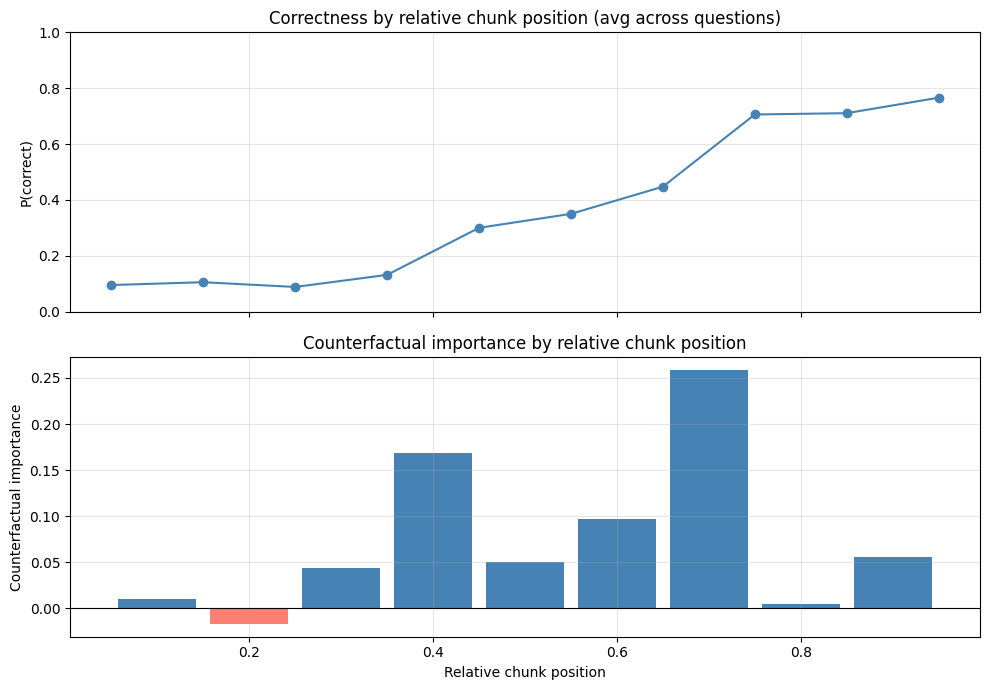

bin P(correct): ['0.095', '0.105', '0.088', '0.132', '0.300', '0.350', '0.447', '0.706', '0.711', '0.766']
importance:     ['+0.010', '-0.017', '+0.043', '+0.168', '+0.050', '+0.097', '+0.259', '+0.005', '+0.055']


In [ ]:
def is_correct(item):
    if 'prefill_correctness' not in item:
        return False
    return item['prefill_correctness']['correctness'] in ('correct', 'partially_correct')

# Per-question: {chunk_index -> correct}
q_data = {}
for item in graded:
    qid = item['question_id']
    ci = int(item['chunk_index'])
    if qid not in q_data:
        q_data[qid] = {}
    q_data[qid][ci] = is_correct(item)

# Normalize chunk position to [0, 1]: -1 -> 0.0, max_ci -> 1.0
n_bins = 10
bin_correctness = [[] for _ in range(n_bins)]

for qid, ci_dict in q_data.items():
    max_ci = max(ci_dict.keys())
    for ci, correct in ci_dict.items():
        rel = (ci + 1) / (max_ci + 1)
        bin_idx = min(int(rel * n_bins), n_bins - 1)
        bin_correctness[bin_idx].append(correct)

bin_prob = pd.Series([np.mean(b) if b else np.nan for b in bin_correctness]).ffill().bfill().values
importance = np.diff(bin_prob)

bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
imp_centers = (bin_centers[:-1] + bin_centers[1:]) / 2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(bin_centers, bin_prob, marker='o', color='steelblue')
ax1.set_ylabel('P(correct)')
ax1.set_title('Correctness by relative chunk position (avg across questions)')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

ax2.bar(imp_centers, importance, width=0.085,
        color=['salmon' if x < 0 else 'steelblue' for x in importance])
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Relative chunk position')
ax2.set_ylabel('Counterfactual importance')
ax2.set_title('Counterfactual importance by relative chunk position')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('bin P(correct):', [f"{p:.3f}" for p in bin_prob])
print('importance:    ', [f"{i:+.3f}" for i in importance])

In [ ]:
# When we generate the rollouts:
# one metric is the right answer; one metric is legibility (per chunk), one is presence of non-english characters (for each chunk); one metric is entropy (for each chunk); one metric is KL divergence (for each chunk).
# Given that the model previously produced illegible/non english reasoning, how likely is it to continue?

In [20]:
from dataclasses import dataclass

@dataclass
class RolloutResults:
    question_id: str
    original_results: pd.DataFrame
    forced_answer: pd.DataFrame
    forced_answer_graded: pd.DataFrame
    counterfactual: pd.DataFrame
    counterfactual_graded: pd.DataFrame

def load_rollout_results(question_id):
    folder = question_id
    original_results = f"{folder}/original_answer.json"
    forced_answer = f"{folder}/forced_answer.json"
    forced_answer_graded = f"{folder}/forced_answer_graded.json"
    counterfactual = f"{folder}/counterfactual.json"
    counterfactual_graded = f"{folder}/counterfactual_graded.json"


    with open(original_results) as f:
        gpqa_question = json.load(f)

    with open(forced_answer) as f:
        forced_answer_data = json.load(f)["results"]

    with open(forced_answer_graded) as f:
        forced_answer_graded_data = json.load(f)["results"]
    
    with open(counterfactual) as f:
        counterfactual_data = json.load(f)["results"]

    with open(counterfactual_graded) as f:
        counterfactual_graded_data = json.load(f)["results"]

    df_question = pd.DataFrame(gpqa_question)
    df_forced_answer = pd.DataFrame(forced_answer_data)
    df_counterfactual = pd.DataFrame(counterfactual_data)
    for d in [df_forced_answer, df_counterfactual]:
        d["prefill_error"] = d["metadata"].apply(lambda m: m.get("error") if m else None)

    df_forced_answer_graded = pd.DataFrame(forced_answer_graded_data)
    df_counterfactual_graded = pd.DataFrame(counterfactual_graded_data)
    for d in [df_forced_answer_graded, df_counterfactual_graded]:
        d["prefill_error"] = d["metadata"].apply(lambda m: m.get("error") if m else None)
        d["grading_error"] = d["prefill_correctness"].isna()
        d["prefill_correctness"] = d["prefill_correctness"].apply(lambda x: x["correctness"] if isinstance(x, dict) else None)
    return RolloutResults(
        question_id=question_id,
        original_results=df_question,
        forced_answer=df_forced_answer,
        counterfactual=df_counterfactual,
        forced_answer_graded=df_forced_answer_graded,
        counterfactual_graded=df_counterfactual_graded,
    )

In [21]:
gpqa_49 = load_rollout_results("gpqa_49")

In [ ]:
def calculate_forced_answer_importances(graded_results):
    filtered = graded_results[graded_results["prefill_error"].isna() & ~graded_results["grading_error"]]
    pct_correct_by_chunk = filtered.groupby("chunk_index").agg(
        correct_pct=("prefill_correctness", lambda x: (x == "correct").mean()),
    )
    pct_correct_by_chunk = pct_correct_by_chunk.reindex(
        range(pct_correct_by_chunk.index.min(), pct_correct_by_chunk.index.max() + 1)
    )
    pct_correct_by_chunk["delta"] = pct_correct_by_chunk["correct_pct"].diff()
    return pct_correct_by_chunk


In [25]:
import plotly.graph_objects as go

def plot_forced_answer_importance(rollout_results: RolloutResults):
    importances = calculate_forced_answer_importances(rollout_results.forced_answer_graded)

    chunk_prefills = rollout_results.forced_answer.groupby("chunk_index")["chunk"].first()
    hover_text = [
        (str(chunk_prefills.get(i, ""))[-100:] or "(no prefill)")
        for i in importances.index
    ]

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=list(importances.index),
        y=importances["delta"],
        opacity=0.7,
        hovertemplate="<b>Chunk %{x}</b><br>Delta: %{y:.4f}<br>...%{customdata}<extra></extra>",
        customdata=hover_text,
    ))
    fig.add_hline(y=0, line_color="black", line_width=0.5)
    fig.update_layout(
        title=f"Forced Answer Importance by Chunk {rollout_results.question_id}",
        xaxis_title="Chunk Index",
        yaxis_title="Correct % Delta",
        width=900,
        height=400,
    )
    fig.show()

In [24]:
plot_forced_answer_importance(gpqa_49)

In [ ]:
def plot_resampling_importance(rollout_results: RolloutResults):
    importances = calculate_forced_answer_importances(rollout_results.counterfactual_graded)

    chunk_prefills = rollout_results.counterfactual.groupby("chunk_index")["chunk"].first()
    hover_text = [
        (str(chunk_prefills.get(i, ""))[-100:] or "(no prefill)")
        for i in importances.index
    ]

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=list(importances.index),
        y=importances["delta"],
        opacity=0.7,
        hovertemplate="<b>Chunk %{x}</b><br>Delta: %{y:.4f}<br>...%{customdata}<extra></extra>",
        customdata=hover_text,
    ))
    fig.add_hline(y=0, line_color="black", line_width=0.5)
    fig.update_layout(
        title=f"Resampling Importance by Chunk ({rollout_results.question_id})",
        xaxis_title="Chunk Index",
        yaxis_title="Correct % Delta",
        width=900,
        height=400,
    )
    fig.show()

In [27]:
plot_resampling_importance(gpqa_49)

In [ ]:
ind = gpqa_49.counterfactual_graded["chunk_index"].unique()
print(sorted(ind))

[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), n

97

In [38]:
def boxed_token_span(text: str, tokenizer) -> tuple[int | None, int | None]:
    m = re.search(r"\\boxed\{(.+?)\}", text)
    if not m:
        return None, None

    enc = tokenizer(text, return_offsets_mapping=True)
    offsets = enc["offset_mapping"]
    start_char, end_char = m.start(1), m.end(1)

    start_tok = next((i for i, (s, e) in enumerate(offsets) if s <= start_char < e), None)
    end_tok = next((i for i, (s, e) in enumerate(offsets) if s < end_char <= e), None)
    return start_tok, end_tok